# DNSC 6330: Responsible Machine Learning — Capstone Project

**George Washington University | Spring 2026**

Surafel Debebe, Xiaowei Cen, Percy Rodriguez, Suzy Tseng, Ramin Gamzaev 

---

## Project Overview

This notebook implements an end-to-end responsible machine learning audit on the 2024 Home Mortgage Disclosure Act (HMDA) Loan Application Register (LAR). The objective is not only to build predictive models, but also to evaluate whether those models are defensible under fairness, reliability, and deployment-governance criteria.

**Dataset:** 2024 HMDA LAR (pipe-delimited), filtered to `action_taken ∈ {1, 2, 3}` and capped at 150,000 rows for reproducible analysis.

**Label:** action taken 1 and 2 → approved (`1`); action taken 3 → denied (`0`).

**Models:** Logistic Regression (interpretable baseline) and Gradient Boosting Classifier (higher-capacity model).

**Notebook map to capstone questions**
1. **Q1 — Optimization objective**  
2. **Q3 — Subgroup error measurement**  
3. **Q2 — Known failure modes**  
4. **Q4 — Mitigation and residual risk**  
5. **Q5 — Deployment defensibility**

The notebook follows the analysis order used to produce the evidence, while each section is explicitly mapped to the five capstone questions.

## 1. Import Libraries

Load the Python libraries used for data processing, modeling, evaluation, and feature reliance analysis.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, confusion_matrix
from sklearn.inspection import permutation_importance


## 2. Settings

Define the file path, chunk size, random state, and row limit. Change `FILE_PATH` if your data file is stored in a different location.

In [2]:
# 2) SETTINGS

FILE_PATH = r"C:\Users\a1398\Desktop\Hdesk\Responsible for ML\Capstone\2024_lar.txt"
CHUNK_SIZE = 50_000
RANDOM_STATE = 42
MAX_ROWS_AFTER_FILTER = 150_000


## 3. Feature Choices

Define model features, audit features, numeric features, categorical features, and the columns needed from the HMDA file.

In [3]:
# 3) FEATURE CHOICES
model_features = [
    "loan_amount",
    "income",
    "property_value",
    "loan_term",
    "combined_loan_to_value_ratio",
    "debt_to_income_ratio",
    "loan_type",
    "loan_purpose",
    "lien_status",
    "occupancy_type",
    "preapproval",
    "reverse_mortgage",
    "open_end_line_of_credit",
    "business_or_commercial_purpose",
    "applicant_age",
    "derived_loan_product_type",
    "derived_dwelling_category",
    "construction_method",
    "total_units"
]

audit_features = [
    "derived_race",
    "derived_ethnicity",
    "derived_sex",
    "race_ethnicity"
]

numeric_features = [
    "loan_amount",
    "income",
    "property_value",
    "loan_term",
    "combined_loan_to_value_ratio"
]

categorical_features = [c for c in model_features if c not in numeric_features]

needed_cols = list(set(model_features + ["derived_race", "derived_ethnicity", "derived_sex", "action_taken"]))


## 4. Load Data with Chunk Processing

Read only the needed columns from the large HMDA file, filter for originated/approved/denied loans, create the target label, and combine race and ethnicity for auditing.

In [4]:
# 4) LOAD ONLY NEEDED COLUMNS
chunks = []
total_rows = 0

for chunk in pd.read_csv(
    FILE_PATH,
    sep="|",
    usecols=lambda c: c in needed_cols,
    chunksize=CHUNK_SIZE,
    low_memory=False
):
    chunk = chunk[chunk["action_taken"].isin([1, 2, 3])].copy()

    if len(chunk) == 0:
        continue

    chunk["label"] = chunk["action_taken"].map({1: 1, 2: 1, 3: 0})

    chunk["race_ethnicity"] = (
        chunk["derived_race"].astype(str).str.strip()
        + " | " +
        chunk["derived_ethnicity"].astype(str).str.strip()
    )

    keep_cols = model_features + [
        "derived_race",
        "derived_ethnicity",
        "derived_sex",
        "race_ethnicity",
        "label"
    ]

    chunk = chunk[keep_cols].copy()

    for col in chunk.columns:
        if chunk[col].dtype == "object":
            chunk[col] = chunk[col].astype(str).str.strip()

    chunks.append(chunk)
    total_rows += len(chunk)

    if total_rows >= MAX_ROWS_AFTER_FILTER:
        break

df = pd.concat(chunks, ignore_index=True)
print("Rows loaded:", len(df))


Rows loaded: 154933


## 5. Data Cleaning

Standardize missing values, convert numeric variables, clean categorical/audit columns, and check the basic dataset summary.

In [5]:
# 5) CLEANING
sentinel_map = {
    "Exempt": np.nan,
    "NA": np.nan,
    "N/A": np.nan,
    "nan": np.nan,
    "9999": np.nan,
    "999": np.nan,
    "1111": np.nan,
    "8888": np.nan,
    "888": np.nan,
    "No co-applicant": np.nan,
    "": np.nan
}

for col in df.columns:
    df[col] = df[col].replace(sentinel_map)

for col in numeric_features:
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in categorical_features:
    df[col] = df[col].astype("string")
    df[col] = df[col].fillna("Missing")
    df[col] = df[col].str.strip()

for col in audit_features:
    df[col] = df[col].astype("string")
    df[col] = df[col].fillna("Missing")
    df[col] = df[col].str.strip()

df = df.dropna(subset=["loan_amount", "income", "property_value"], how="all").copy()

print("Rows after cleaning:", len(df))
print("Approval rate:", round(df["label"].mean(), 4))

print("\nDtypes check:")
print(df[model_features].dtypes)

print("\nTop race_ethnicity groups:")
print(df["race_ethnicity"].value_counts().head(10))

print("\nSex groups:")
print(df["derived_sex"].value_counts(dropna=False))


Rows after cleaning: 154933
Approval rate: 0.784

Dtypes check:
loan_amount                                int64
income                                   float64
property_value                           float64
loan_term                                float64
combined_loan_to_value_ratio             float64
debt_to_income_ratio              string[python]
loan_type                         string[python]
loan_purpose                      string[python]
lien_status                       string[python]
occupancy_type                    string[python]
preapproval                       string[python]
reverse_mortgage                  string[python]
open_end_line_of_credit           string[python]
business_or_commercial_purpose    string[python]
applicant_age                     string[python]
derived_loan_product_type         string[python]
derived_dwelling_category         string[python]
construction_method               string[python]
total_units                       string[python]
dtype

## 6. Train-Test Split

Split model features, audit features, and target into training and testing sets using stratification.

In [6]:
# 6) TRAIN / TEST SPLIT

X_model = df[model_features].copy()
X_audit = df[audit_features].copy()
y = df["label"].copy()

X_train, X_test, y_train, y_test, audit_train, audit_test = train_test_split(
    X_model, y, X_audit,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train shape: (123946, 19)
Test shape : (30987, 19)


## 7. Preprocessing Pipeline

Use median imputation and standard scaling for numeric features. Use most frequent imputation and one-hot encoding for categorical features.

In [7]:
# 7) PREPROCESSING

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


## 8. Model Training

Train two models: Logistic Regression and Gradient Boosting.

In [8]:
# 8) MODELS

lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

gbt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ))
])

lr_pipeline.fit(X_train, y_train)
gbt_pipeline.fit(X_train, y_train)

print("LR fitted.")
print("GBT fitted.")


LR fitted.
GBT fitted.


## Question 1: Optimization Objective

### What is optimized during training, and what threshold is used for decisions?

The models are trained to minimize **binary cross-entropy (log loss)**. For model comparison, this notebook prioritizes **test AUC** because the HMDA approval base rate is high and raw accuracy can therefore be inflated by the majority class. Log loss and calibration are reported as secondary checks because the output is used as a probability score, not only as a binary label.

In this run:

- **Training objective:** minimize log loss  
- **Model-selection metric:** maximize test AUC, with calibration and log loss used as supporting evidence  
- **Operating thresholds evaluated later in the audit:**  
  - Logistic Regression = **0.70**  
  - GBT Policy A = **0.65**

### Why this objective fits mortgage lending

This objective reflects two needs at once. First, the model should rank approvals and denials well across applicants. Second, the predicted score should remain interpretable enough to support threshold setting, mitigation, and governance review.

The cost of error is asymmetric:
- a **false denial** can delay or block access to homeownership,
- a **false approval** increases credit-risk exposure and downstream loss.

### Trade-off

A stronger global model is not automatically a more defensible model. Improving overall AUC can still worsen subgroup outcomes, so the optimization objective must always be read together with AIR, FPR/FNR disparity, and deployment constraints.

Logistic Regression
  Train log loss    : 0.3318
  Test  log loss    : 0.3297
  Generalization gap: -0.0021

Gradient Boosting
  Train log loss    : 0.2985
  Test  log loss    : 0.2964
  Generalization gap: -0.0021



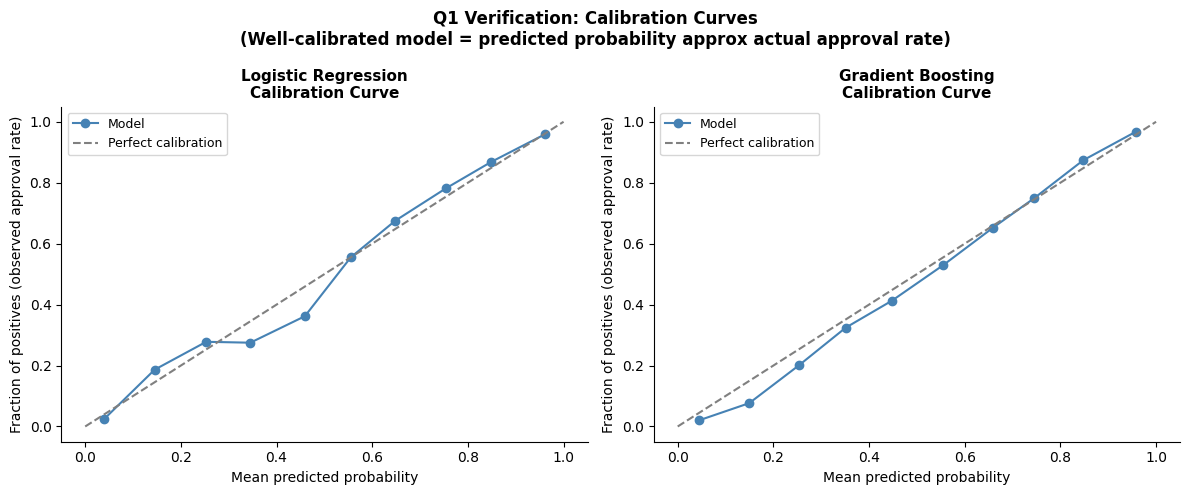

Figure saved: calibration_curves.png


In [9]:
# OPTIMIZATION OBJECTIVE - Verification

# Calibration curves: confirm predicted probabilities track observed approval rates
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, pipeline) in zip(axes, [("Logistic Regression", lr_pipeline),
                                        ("Gradient Boosting",  gbt_pipeline)]):
    prob = pipeline.predict_proba(X_test)[:, 1]
    fraction_of_pos, mean_predicted = calibration_curve(y_test, prob, n_bins=10)

    ax.plot(mean_predicted, fraction_of_pos, marker="o", label="Model", color="steelblue")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives (observed approval rate)")
    ax.set_title(name + "\nCalibration Curve", fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    train_ll = log_loss(y_train, pipeline.predict_proba(X_train)[:, 1])
    test_ll  = log_loss(y_test, prob)
    print(f"{name}")
    print(f"  Train log loss    : {train_ll:.4f}")
    print(f"  Test  log loss    : {test_ll:.4f}")
    print(f"  Generalization gap: {test_ll - train_ll:+.4f}")
    print()

fig.suptitle(
    "Q1 Verification: Calibration Curves\n"
    "(Well-calibrated model = predicted probability approx actual approval rate)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("calibration_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: calibration_curves.png")


## 9. Overall Model Evaluation

Evaluate training and testing accuracy, AUC, log loss, generalization gap, false positive rate, and false negative rate.

In [10]:
# 9) OVERALL EVALUATION

def evaluate_model(name, pipeline, X_train, X_test, y_train, y_test):
    train_prob = pipeline.predict_proba(X_train)[:, 1]
    test_prob = pipeline.predict_proba(X_test)[:, 1]
    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()

    out = {
        "model": name,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "train_auc": roc_auc_score(y_train, train_prob),
        "test_auc": roc_auc_score(y_test, test_prob),
        "train_logloss": log_loss(y_train, train_prob),
        "test_logloss": log_loss(y_test, test_prob),
        "generalization_gap_auc": roc_auc_score(y_train, train_prob) - roc_auc_score(y_test, test_prob),
        "generalization_gap_accuracy": accuracy_score(y_train, train_pred) - accuracy_score(y_test, test_pred),
        "FPR_test": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
        "FNR_test": fn / (fn + tp) if (fn + tp) > 0 else np.nan
    }
    return pd.DataFrame([out]).round(4)

overall_results = pd.concat([
    evaluate_model("Logistic Regression", lr_pipeline, X_train, X_test, y_train, y_test),
    evaluate_model("Gradient Boosting", gbt_pipeline, X_train, X_test, y_train, y_test)
], ignore_index=True)

print("\n=== Overall model results ===")
print(overall_results)



=== Overall model results ===
                 model  train_accuracy  test_accuracy  train_auc  test_auc  \
0  Logistic Regression          0.8623         0.8638     0.8797    0.8817   
1    Gradient Boosting          0.8757         0.8761     0.9047    0.9063   

   train_logloss  test_logloss  generalization_gap_auc  \
0         0.3318        0.3297                 -0.0019   
1         0.2985        0.2964                 -0.0016   

   generalization_gap_accuracy  FPR_test  FNR_test  
0                      -0.0015    0.4836    0.0405  
1                      -0.0004    0.4013    0.0475  


### Conclusion from overall evaluation

GBT outperforms LR on discrimination and log loss, so it is the stronger predictive model on the held-out test set. However, this does **not** settle the audit. Later sections show that the better-performing model can still produce larger subgroup disparities and fail the deployment gate under fair-lending constraints.

## 10. Feature Reliance

Use permutation importance to estimate which features the models rely on most.

In [11]:
# 10) FEATURE RELIANCE

def get_permutation_importance(pipeline, X, y, top_n=15):
    result = permutation_importance(
        pipeline, X, y,
        n_repeats=5,
        random_state=RANDOM_STATE,
        scoring="roc_auc"
    )
    importances = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values("importance_mean", ascending=False)
    return importances.head(top_n)

print("\n=== Top permutation importance: LR ===")
print(get_permutation_importance(lr_pipeline, X_test, y_test))

print("\n=== Top permutation importance: GBT ===")
print(get_permutation_importance(gbt_pipeline, X_test, y_test))



=== Top permutation importance: LR ===
                         feature  importance_mean  importance_std
7                   loan_purpose         0.196472        0.002267
5           debt_to_income_ratio         0.091790        0.002153
3                      loan_term         0.014779        0.000997
6                      loan_type         0.008151        0.000610
0                    loan_amount         0.005724        0.000354
15     derived_loan_product_type         0.005591        0.000426
8                    lien_status         0.004008        0.000274
10                   preapproval         0.003680        0.000392
14                 applicant_age         0.001802        0.000259
16     derived_dwelling_category         0.001703        0.000219
17           construction_method         0.001642        0.000231
4   combined_loan_to_value_ratio         0.001369        0.000268
12       open_end_line_of_credit         0.001185        0.000187
9                 occupancy_type    

## 10b. SHAP Feature Importance

This section complements permutation importance by showing how individual features contribute to approval predictions in the GBT model. Unlike permutation importance, SHAP values provide both magnitude and direction: positive values increase the predicted probability of approval, while negative values reduce it.

We apply TreeExplainer to a stratified sample of the test set and report two views of the same model behavior:

1. **SHAP summary plot** - shows the distribution of feature effects across individual applicants.
2. **Mean absolute SHAP values** - provides a global ranking of the most influential variables in the model.

The purpose of this analysis is not only to identify the strongest drivers of prediction, but also to assess whether variables such as loan purpose, loan type, occupancy type, or applicant age may warrant closer review as potential proxy-sensitive features.

SHAP values shape: (1000, 81)  (rows = sample size, cols = 81 encoded features)


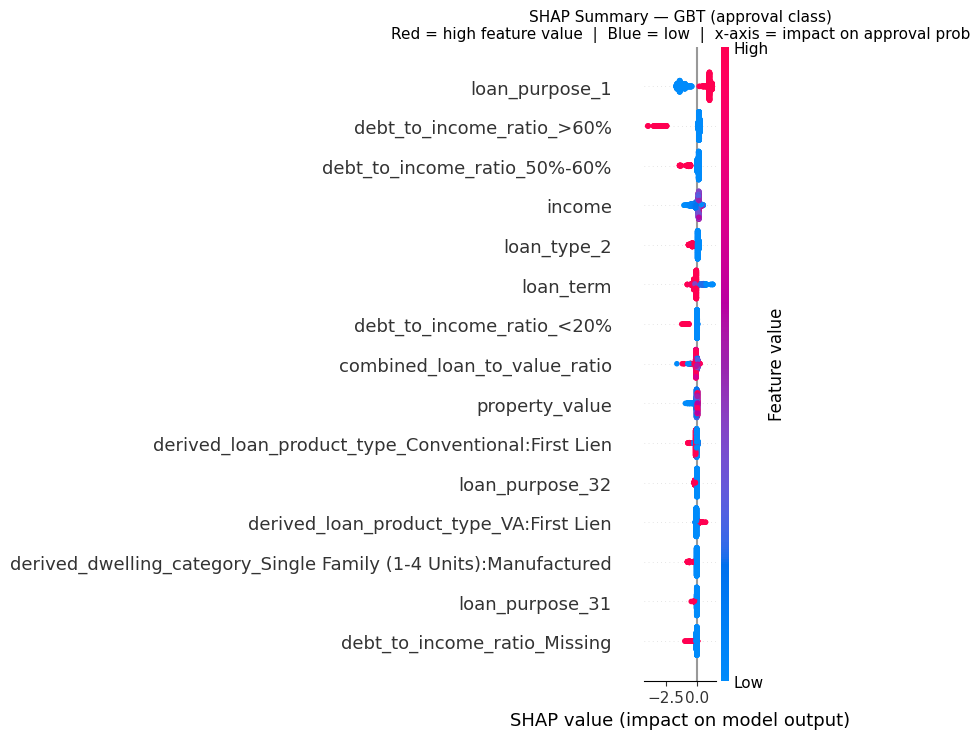

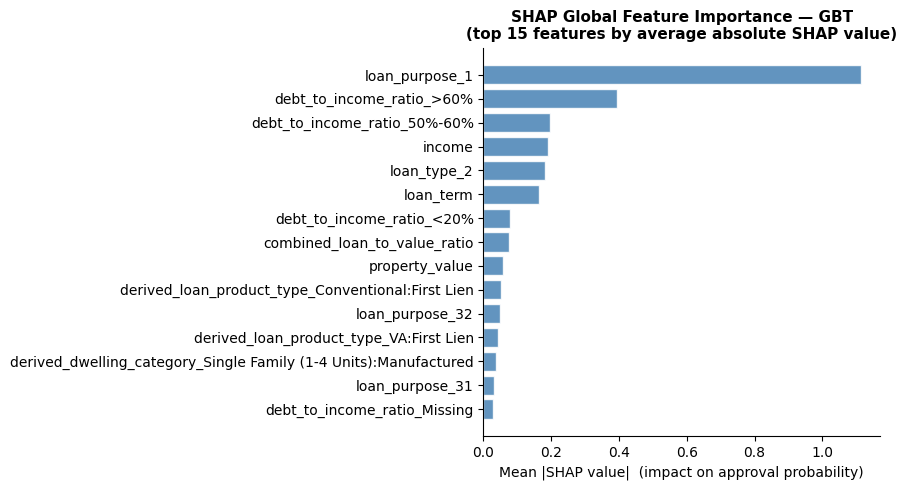


Proxy risk check — features in top-15 SHAP that warrant proxy review:
  loan_purpose                    SHAP rank(s): [1, 11, 14]
  loan_type                       SHAP rank(s): [5]

SHAP figures saved: shap_beeswarm.png, shap_bar.png


In [12]:
# 10b) SHAP FEATURE IMPORTANCE

try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap

import scipy.sparse

# ── Sample 1000 rows from test set (stratified by label) ──
np.random.seed(RANDOM_STATE)
sample_size = min(1000, len(X_test))
sample_idx  = np.random.choice(len(X_test), sample_size, replace=False)
X_shap_raw  = X_test.iloc[sample_idx].reset_index(drop=True)

# ── Transform through preprocessor to get numeric matrix ──
preprocessor_fitted = gbt_pipeline.named_steps["preprocessor"]
X_shap_transformed  = preprocessor_fitted.transform(X_shap_raw)
if scipy.sparse.issparse(X_shap_transformed):
    X_shap_transformed = X_shap_transformed.toarray()

# ── Recover feature names from ColumnTransformer ──
try:
    raw_names = preprocessor_fitted.get_feature_names_out().tolist()
    feat_names = [n.replace("num__", "").replace("cat__", "") for n in raw_names]
except Exception:
    feat_names = [f"feature_{i}" for i in range(X_shap_transformed.shape[1])]

# ── SHAP TreeExplainer on GBT classifier ──
gbt_clf  = gbt_pipeline.named_steps["classifier"]
explainer = shap.TreeExplainer(gbt_clf)
shap_vals = explainer.shap_values(X_shap_transformed)

# For binary GBT sklearn returns a 2-D array (approval class directly)
# Some shap versions return a list — take index [1] if so
if isinstance(shap_vals, list):
    shap_vals = shap_vals[1]

print(f"SHAP values shape: {shap_vals.shape}  "
      f"(rows = sample size, cols = {X_shap_transformed.shape[1]} encoded features)")

# ── Plot 1: Beeswarm summary (top 15 features) ──
shap.summary_plot(
    shap_vals, X_shap_transformed,
    feature_names=feat_names,
    max_display=15,
    show=False
)
plt.title("SHAP Summary — GBT (approval class)\n"
          "Red = high feature value  |  Blue = low  |  x-axis = impact on approval prob",
          fontsize=11)
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: Mean |SHAP| bar chart ──
mean_abs_shap = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=feat_names
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(mean_abs_shap.index[::-1], mean_abs_shap.values[::-1],
        color="steelblue", alpha=0.85, edgecolor="white")
ax.set_xlabel("Mean |SHAP value|  (impact on approval probability)")
ax.set_title("SHAP Global Feature Importance — GBT\n"
             "(top 15 features by average absolute SHAP value)",
             fontsize=11, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Proxy risk flag ──
proxy_candidates = ["loan_purpose", "loan_type", "occupancy_type", "applicant_age",
                    "construction_method", "total_units"]
top15_names = mean_abs_shap.index.tolist()
flagged_proxies = [f for f in proxy_candidates
                   if any(f in n for n in top15_names)]
print()
if flagged_proxies:
    print(f"Proxy risk check — features in top-15 SHAP that warrant proxy review:")
    for fp in flagged_proxies:
        matched = [n for n in top15_names if fp in n]
        rank    = [top15_names.index(m) + 1 for m in matched]
        print(f"  {fp:30s}  SHAP rank(s): {rank}")
else:
    print("No high-priority proxy candidates in top-15 SHAP features.")
print("\nSHAP figures saved: shap_beeswarm.png, shap_bar.png")


## 11. Fairness Analysis: Group Metrics

This section reports group-level performance metrics across the main protected-attribute dimensions used in the audit. For each subgroup, we summarize approval rate, accuracy, AUC, false positive rate, false negative rate, and true positive rate.

These descriptive metrics provide the first view of how model behavior differs across applicant groups before turning to the formal disparity measures reported later in the notebook.

In [13]:
# 11) GROUP METRICS

def safe_div(a, b):
    return a / b if b != 0 else np.nan

def compute_group_metrics(pipeline, X, y, group_series, min_n=50):
    pred = pipeline.predict(X)
    prob = pipeline.predict_proba(X)[:, 1]

    temp = pd.DataFrame({
        "group": group_series.reset_index(drop=True),
        "actual": y.reset_index(drop=True),
        "pred": pred,
        "prob": prob
    })

    rows = []
    for g, gdf in temp.groupby("group"):
        if len(gdf) < min_n:
            continue

        tn, fp, fn, tp = confusion_matrix(gdf["actual"], gdf["pred"], labels=[0, 1]).ravel()

        rows.append({
            "group": g,
            "n": len(gdf),
            "approval_rate": gdf["pred"].mean(),
            "accuracy": accuracy_score(gdf["actual"], gdf["pred"]),
            "AUC": roc_auc_score(gdf["actual"], gdf["prob"]) if gdf["actual"].nunique() > 1 else np.nan,
            "FPR": safe_div(fp, fp + tn),
            "FNR": safe_div(fn, fn + tp),
            "TPR": safe_div(tp, tp + fn)
        })

    return pd.DataFrame(rows).sort_values(["n", "group"], ascending=[False, True]).reset_index(drop=True)

def compute_air(pipeline, X, group_series, reference_group, min_n=50):
    pred = pipeline.predict(X)
    temp = pd.DataFrame({
        "group": group_series.reset_index(drop=True),
        "pred": pred
    })

    counts = temp["group"].value_counts()
    valid_groups = counts[counts >= min_n].index
    temp = temp[temp["group"].isin(valid_groups)].copy()

    rates = temp.groupby("group")["pred"].mean()
    if reference_group not in rates.index:
        print(f"Reference group not found: {reference_group}")
        print("Available groups:")
        print(rates.sort_values(ascending=False))
        return pd.DataFrame(columns=["group", "approval_rate", "AIR"])

    ref_rate = rates.loc[reference_group]
    out = pd.DataFrame({
        "group": rates.index,
        "approval_rate": rates.values,
        "AIR": rates.values / ref_rate
    }).sort_values("AIR").reset_index(drop=True)

    return out

print("\n=== GBT group metrics: race_ethnicity ===")
gbt_race_eth = compute_group_metrics(gbt_pipeline, X_test, y_test, audit_test["race_ethnicity"])
print(gbt_race_eth.round(4))

print("\n=== GBT group metrics: sex ===")
gbt_sex = compute_group_metrics(gbt_pipeline, X_test, y_test, audit_test["derived_sex"])
print(gbt_sex.round(4))



=== GBT group metrics: race_ethnicity ===
                                                group      n  approval_rate  \
0                      White | Not Hispanic or Latino  17258         0.8514   
1        Race Not Available | Ethnicity Not Available   3206         0.8837   
2   Black or African American | Not Hispanic or La...   2789         0.6795   
3                          White | Hispanic or Latino   2439         0.7839   
4                      Asian | Not Hispanic or Latino   1229         0.8918   
5                                       White | Joint    736         0.8995   
6             Race Not Available | Hispanic or Latino    729         0.7819   
7                      Joint | Not Hispanic or Latino    634         0.8912   
8         Race Not Available | Not Hispanic or Latino    494         0.7206   
9                     White | Ethnicity Not Available    336         0.8750   
10                                      Joint | Joint    150         0.9133   
11  Ameri

## 12. Simple Recourse Probe

This diagnostic examines whether small changes in selected actionable features lead to meaningful changes in predicted approval probability. The purpose is not to build a full recourse system, but to assess whether the model score is sensitive to plausible modifications in applicant or loan characteristics.

In [14]:
# 12) SIMPLE RECOURSE PROBE

def simple_recourse_probe(pipeline, X, features_to_shift):
    rows = []
    base_prob = pipeline.predict_proba(X)[:, 1]

    for feature, new_value in features_to_shift.items():
        X_cf = X.copy()
        X_cf[feature] = new_value
        cf_prob = pipeline.predict_proba(X_cf)[:, 1]
        rows.append({
            "feature_changed": feature,
            "new_value": str(new_value),
            "avg_prob_change": np.mean(cf_prob - base_prob),
            "median_prob_change": np.median(cf_prob - base_prob)
        })

    return pd.DataFrame(rows).sort_values("avg_prob_change", ascending=False)

probe = simple_recourse_probe(
    gbt_pipeline,
    X_test.sample(n=min(3000, len(X_test)), random_state=RANDOM_STATE),
    {
        "occupancy_type": X_train["occupancy_type"].mode().iloc[0],
        "lien_status": X_train["lien_status"].mode().iloc[0]
    }
)

print("\n=== Simple recourse probe (GBT) ===")
print(probe.round(4))



=== Simple recourse probe (GBT) ===
  feature_changed new_value  avg_prob_change  median_prob_change
1     lien_status         1           0.0003                 0.0
0  occupancy_type         1          -0.0019                 0.0


## 12. Subgroup Fairness Analysis

This section reports the main disparity measures used in the audit:

- **AIR (Adverse Impact Ratio)** - approval rate of a group divided by the approval rate of the reference group  
- **ME (Marginal Effect)** - difference in approval rates, with a two-proportion z-test for statistical significance  
- **SMD (Standardized Mean Difference)** - effect size on continuous probability scores  

The analysis is applied to race, sex, and ethnicity for both Logistic Regression and Gradient Boosting. Reference groups are defined as White, Male, and Not Hispanic or Latino. A primary regulatory concern is flagged when **AIR < 0.80**.

In [15]:
# 12) FAIRNESS PACKAGE SETUP

from scipy import stats

def compute_disparity_table(pipeline, X, y, group_series, reference_group, min_n=50, label=None):
    """
    Full disparity table: AIR, ME (+ z-test p-value), SMD (Cohen's d on prob scores).

    Parameters
    ----------
    pipeline        : fitted sklearn Pipeline
    X               : feature DataFrame (test set)
    y               : true labels (test set)
    group_series    : pd.Series of group membership, aligned with X / y
    reference_group : string – the privileged reference group
    min_n           : minimum group size to include
    label           : optional string to prefix printed header

    Returns
    -------
    pd.DataFrame with one row per group
    """
    from scipy import stats

    pred  = pipeline.predict(X)
    prob  = pipeline.predict_proba(X)[:, 1]

    frame = pd.DataFrame({
        "group"  : group_series.reset_index(drop=True),
        "actual" : y.reset_index(drop=True),
        "pred"   : pred,
        "prob"   : prob
    })

    # filter small groups
    counts = frame["group"].value_counts()
    valid  = counts[counts >= min_n].index
    frame  = frame[frame["group"].isin(valid)].copy()

    if reference_group not in frame["group"].values:
        avail = frame["group"].unique().tolist()
        raise ValueError(f"Reference group '{reference_group}' not found. Available: {avail}")

    ref_df        = frame[frame["group"] == reference_group]
    ref_rate      = ref_df["pred"].mean()          # reference approval rate
    ref_n         = len(ref_df)
    ref_prob_mean = ref_df["prob"].mean()
    ref_prob_std  = ref_df["prob"].std(ddof=1)

    rows = []
    for g, gdf in frame.groupby("group"):
        n          = len(gdf)
        rate       = gdf["pred"].mean()
        air        = rate / ref_rate if ref_rate > 0 else np.nan
        me         = rate - ref_rate

        # Two-proportion z-test for ME
        count_g    = gdf["pred"].sum()
        count_ref  = ref_df["pred"].sum()
        p_pool     = (count_g + count_ref) / (n + ref_n)
        se         = np.sqrt(p_pool * (1 - p_pool) * (1/n + 1/ref_n))
        z_stat     = me / se if se > 0 else 0.0
        p_val      = 2 * stats.norm.sf(abs(z_stat))

        # SMD (Cohen's d on continuous probability scores)
        g_prob_mean = gdf["prob"].mean()
        g_prob_std  = gdf["prob"].std(ddof=1)
        pooled_sd   = np.sqrt((g_prob_std**2 + ref_prob_std**2) / 2)
        smd         = (g_prob_mean - ref_prob_mean) / pooled_sd if pooled_sd > 0 else 0.0

        # FPR / FNR per group
        tn_g, fp_g, fn_g, tp_g = confusion_matrix(
            gdf["actual"], gdf["pred"], labels=[0, 1]
        ).ravel()
        fpr_g = fp_g / (fp_g + tn_g) if (fp_g + tn_g) > 0 else np.nan
        fnr_g = fn_g / (fn_g + tp_g) if (fn_g + tp_g) > 0 else np.nan

        rows.append({
            "group"       : g,
            "n"           : n,
            "approval_rate": round(rate, 4),
            "AIR"         : round(air, 4),
            "flag_AIR"    : "⚑" if air < 0.80 else "",
            "ME"          : round(me, 4),
            "z_stat"      : round(z_stat, 3),
            "p_value"     : round(p_val, 4),
            "flag_ME"     : "*" if p_val < 0.05 else "",
            "SMD"         : round(smd, 4),
            "flag_SMD"    : "⚑" if abs(smd) >= 0.20 else "",
            "FPR"         : round(fpr_g, 4),
            "FNR"         : round(fnr_g, 4),
        })

    result = pd.DataFrame(rows).sort_values("AIR").reset_index(drop=True)

    hdr = f"\n{'='*70}\n  Disparity Table"
    if label:
        hdr += f" — {label}"
    hdr += f"  |  reference: '{reference_group}'\n{'='*70}"
    print(hdr)
    print(result.to_string(index=False))
    print(f"\nFlag legend:  ⚑ AIR < 0.80 or |SMD| ≥ 0.20   * ME p < 0.05 (two-sided z-test)")
    return result

print("compute_disparity_table() defined.")


compute_disparity_table() defined.


### 12.1 Logistic Regression — Race Disparities

Reference group: **White** (largest group; EEOC uses most-favored class as reference).

In [16]:
lr_race = compute_disparity_table(
    lr_pipeline, X_test, y_test,
    group_series    = audit_test["derived_race"],
    reference_group = "White",
    label           = "LR | derived_race"
)



  Disparity Table — LR | derived_race  |  reference: 'White'
                                    group     n  approval_rate    AIR flag_AIR      ME  z_stat  p_value flag_ME     SMD flag_SMD    FPR    FNR
Native Hawaiian or Other Pacific Islander    83         0.7229 0.8340          -0.1439  -3.845   0.0001       * -0.4017        ⚑ 0.4412 0.0816
         American Indian or Alaska Native   232         0.7328 0.8453          -0.1341  -5.949   0.0000       * -0.3179        ⚑ 0.3882 0.0680
                Black or African American  3074         0.7498 0.8650          -0.1170 -17.035   0.0000       * -0.3481        ⚑ 0.4088 0.0625
                                    White 20769         0.8668 1.0000           0.0000   0.000   1.0000          0.0000          0.4951 0.0411
                       Race Not Available  4508         0.8671 1.0004           0.0003   0.055   0.9565          0.0391          0.5175 0.0333
                 2 or more minority races   121         0.8678 1.0011           

### 12.2 Gradient Boosting — Race Disparities

Same reference group (White). Compare AIR and SMD against the LR baseline.

In [17]:
gbt_race = compute_disparity_table(
    gbt_pipeline, X_test, y_test,
    group_series    = audit_test["derived_race"],
    reference_group = "White",
    label           = "GBT | derived_race"
)



  Disparity Table — GBT | derived_race  |  reference: 'White'
                                    group     n  approval_rate    AIR flag_AIR      ME  z_stat  p_value flag_ME     SMD flag_SMD    FPR    FNR
                Black or African American  3074         0.6949 0.8217          -0.1507 -20.581   0.0000       * -0.3504        ⚑ 0.2915 0.0832
         American Indian or Alaska Native   232         0.6983 0.8258          -0.1473  -6.149   0.0000       * -0.3361        ⚑ 0.3176 0.0816
Native Hawaiian or Other Pacific Islander    83         0.7470 0.8834          -0.0986  -2.478   0.0132       * -0.3310        ⚑ 0.4412 0.0408
                 2 or more minority races   121         0.8182 0.9676          -0.0274  -0.832   0.4057         -0.0967          0.4706 0.0460
                                    White 20769         0.8456 1.0000           0.0000   0.000   1.0000          0.0000          0.4153 0.0479
                       Race Not Available  4508         0.8496 1.0047          

### 12.3 Both Models — Sex Disparities

Reference group: **Male**.

In [18]:
lr_sex = compute_disparity_table(
    lr_pipeline, X_test, y_test,
    group_series    = audit_test["derived_sex"],
    reference_group = "Male",
    label           = "LR | derived_sex"
)

gbt_sex = compute_disparity_table(
    gbt_pipeline, X_test, y_test,
    group_series    = audit_test["derived_sex"],
    reference_group = "Male",
    label           = "GBT | derived_sex"
)



  Disparity Table — LR | derived_sex  |  reference: 'Male'
            group     n  approval_rate    AIR flag_AIR      ME  z_stat  p_value flag_ME     SMD flag_SMD    FPR    FNR
           Female  7589         0.8139 0.9697          -0.0254  -4.478      0.0       * -0.0681          0.4291 0.0462
             Male 10532         0.8393 1.0000           0.0000   0.000      1.0          0.0000          0.4791 0.0435
            Joint 11063         0.8941 1.0652           0.0547  11.850      0.0       *  0.2104        ⚑ 0.5306 0.0361
Sex Not Available  1803         0.9090 1.0830           0.0697   7.648      0.0       *  0.3172        ⚑ 0.6086 0.0300

Flag legend:  ⚑ AIR < 0.80 or |SMD| ≥ 0.20   * ME p < 0.05 (two-sided z-test)

  Disparity Table — GBT | derived_sex  |  reference: 'Male'
            group     n  approval_rate    AIR flag_AIR      ME  z_stat  p_value flag_ME     SMD flag_SMD    FPR    FNR
           Female  7589         0.7832 0.9641          -0.0291  -4.840      0.0       

### 12.4 Both Models — Ethnicity Disparities

Reference group: **Not Hispanic or Latino**.

In [19]:
lr_eth = compute_disparity_table(
    lr_pipeline, X_test, y_test,
    group_series    = audit_test["derived_ethnicity"],
    reference_group = "Not Hispanic or Latino",
    label           = "LR | derived_ethnicity"
)

gbt_eth = compute_disparity_table(
    gbt_pipeline, X_test, y_test,
    group_series    = audit_test["derived_ethnicity"],
    reference_group = "Not Hispanic or Latino",
    label           = "GBT | derived_ethnicity"
)



  Disparity Table — LR | derived_ethnicity  |  reference: 'Not Hispanic or Latino'
                  group     n  approval_rate    AIR flag_AIR      ME  z_stat  p_value flag_ME     SMD flag_SMD    FPR    FNR
     Hispanic or Latino  3489         0.8255 0.9679          -0.0274  -4.209      0.0       * -0.1065          0.4909 0.0323
 Not Hispanic or Latino 22710         0.8528 1.0000           0.0000   0.000      1.0          0.0000          0.4692 0.0443
Ethnicity Not Available  3711         0.8903 1.0440           0.0375   6.067      0.0       *  0.1799          0.5443 0.0308
                  Joint  1076         0.9238 1.0832           0.0710   6.478      0.0       *  0.2619        ⚑ 0.6025 0.0197

Flag legend:  ⚑ AIR < 0.80 or |SMD| ≥ 0.20   * ME p < 0.05 (two-sided z-test)

  Disparity Table — GBT | derived_ethnicity  |  reference: 'Not Hispanic or Latino'
                  group     n  approval_rate    AIR flag_AIR      ME  z_stat  p_value flag_ME     SMD flag_SMD    FPR    FNR
  

### 12.5 Cross-Model Summary — Flagged Disparities

Consolidate all flagged groups (AIR < 0.80, |SMD| ≥ 0.20, ME p < 0.05) across both models into one regulator-ready table.

In [20]:
def flag_summary(df, model_name, axis_label):
    flagged = df[(df["flag_AIR"] != "") | (df["flag_ME"] != "") | (df["flag_SMD"] != "")].copy()
    flagged.insert(0, "model", model_name)
    flagged.insert(1, "axis", axis_label)
    return flagged

summary_parts = [
    flag_summary(lr_race,  "LR",  "race"),
    flag_summary(gbt_race, "GBT", "race"),
    flag_summary(lr_sex,   "LR",  "sex"),
    flag_summary(gbt_sex,  "GBT", "sex"),
    flag_summary(lr_eth,   "LR",  "ethnicity"),
    flag_summary(gbt_eth,  "GBT", "ethnicity"),
]

flagged_summary = pd.concat(summary_parts, ignore_index=True)

display_cols = ["model", "axis", "group", "n", "approval_rate",
                "AIR", "flag_AIR", "ME", "p_value", "flag_ME", "SMD", "flag_SMD"]

print("\n=== Flagged disparities (regulator-facing summary) ===")
if len(flagged_summary) == 0:
    print("No groups flagged under any threshold.")
else:
    print(flagged_summary[display_cols].to_string(index=False))
    print(f"\nTotal flagged group-model pairs: {len(flagged_summary)}")



=== Flagged disparities (regulator-facing summary) ===
model      axis                                     group     n  approval_rate    AIR flag_AIR      ME  p_value flag_ME     SMD flag_SMD
   LR      race Native Hawaiian or Other Pacific Islander    83         0.7229 0.8340          -0.1439   0.0001       * -0.4017        ⚑
   LR      race          American Indian or Alaska Native   232         0.7328 0.8453          -0.1341   0.0000       * -0.3179        ⚑
   LR      race                 Black or African American  3074         0.7498 0.8650          -0.1170   0.0000       * -0.3481        ⚑
   LR      race                                     Asian  1360         0.8993 1.0374           0.0324   0.0006       *  0.2289        ⚑
   LR      race                                     Joint   839         0.9190 1.0601           0.0521   0.0000       *  0.2120        ⚑
  GBT      race                 Black or African American  3074         0.6949 0.8217          -0.1507   0.0000       * -0

## 13. Intersectional Analysis — Race × Sex

Single-axis fairness summaries can understate harm when disparities are concentrated in combined subgroups. For that reason, this section evaluates race × sex intersections using White | Male as the reference group and applies the same disparity metrics used in the one-dimensional audits.

The goal is to determine whether subgroup combinations reveal risks that are not visible in race-only or sex-only summaries.

In [21]:
# 13) INTERSECTIONAL ANALYSIS

# Build race x sex label on the test-set audit columns
intersect_series = (
    audit_test["derived_race"].reset_index(drop=True).astype(str)
    + " | "
    + audit_test["derived_sex"].reset_index(drop=True).astype(str)
)

# Show the subgroup counts so we can pick a sensible min_n
print("Race × Sex subgroup counts (test set):")
print(intersect_series.value_counts().to_string())


Race × Sex subgroup counts (test set):
White | Joint                                           8220
White | Male                                            7528
White | Female                                          4946
Race Not Available | Sex Not Available                  1693
Black or African American | Female                      1379
Race Not Available | Male                               1184
Black or African American | Male                        1038
Race Not Available | Joint                               925
Joint | Joint                                            777
Race Not Available | Female                              706
Black or African American | Joint                        646
Asian | Male                                             552
Asian | Joint                                            423
Asian | Female                                           373
American Indian or Alaska Native | Male                  116
American Indian or Alaska Native | Female     

In [22]:
# Run intersectional disparity table — both models
# Minimum n = 100 to keep cells reliable; raise/lower as needed.
lr_intersect = compute_disparity_table(
    lr_pipeline, X_test, y_test,
    group_series    = intersect_series,
    reference_group = "White | Male",
    min_n           = 100,
    label           = "LR | race × sex"
)

gbt_intersect = compute_disparity_table(
    gbt_pipeline, X_test, y_test,
    group_series    = intersect_series,
    reference_group = "White | Male",
    min_n           = 100,
    label           = "GBT | race × sex"
)



  Disparity Table — LR | race × sex  |  reference: 'White | Male'
                                  group    n  approval_rate    AIR flag_AIR      ME  z_stat  p_value flag_ME     SMD flag_SMD    FPR    FNR
American Indian or Alaska Native | Male  116         0.6897 0.8102          -0.1616  -4.820   0.0000       * -0.3510        ⚑ 0.3542 0.0735
     Black or African American | Female 1379         0.7099 0.8340          -0.1413 -12.821   0.0000       * -0.3683        ⚑ 0.3529 0.0806
       Black or African American | Male 1038         0.7543 0.8862          -0.0969  -7.972   0.0000       * -0.2851        ⚑ 0.4458 0.0546
            Race Not Available | Female  706         0.8144 0.9568          -0.0368  -2.603   0.0092       * -0.0955          0.4519 0.0341
              Race Not Available | Male 1184         0.8218 0.9654          -0.0294  -2.617   0.0089       * -0.0551          0.4866 0.0459
      Black or African American | Joint  646         0.8266 0.9711          -0.0246  -1.677  

## 14. FPR and FNR Disparity Visualization

This figure compares false positive and false negative rates across racial groups for both models. The purpose is to determine whether disparity is limited to selection rates or also appears in the distribution of model errors.

If subgroup FPR and FNR differ materially from the overall baseline, the model may impose unequal denial and approval mistakes across applicants even when aggregate performance remains strong.

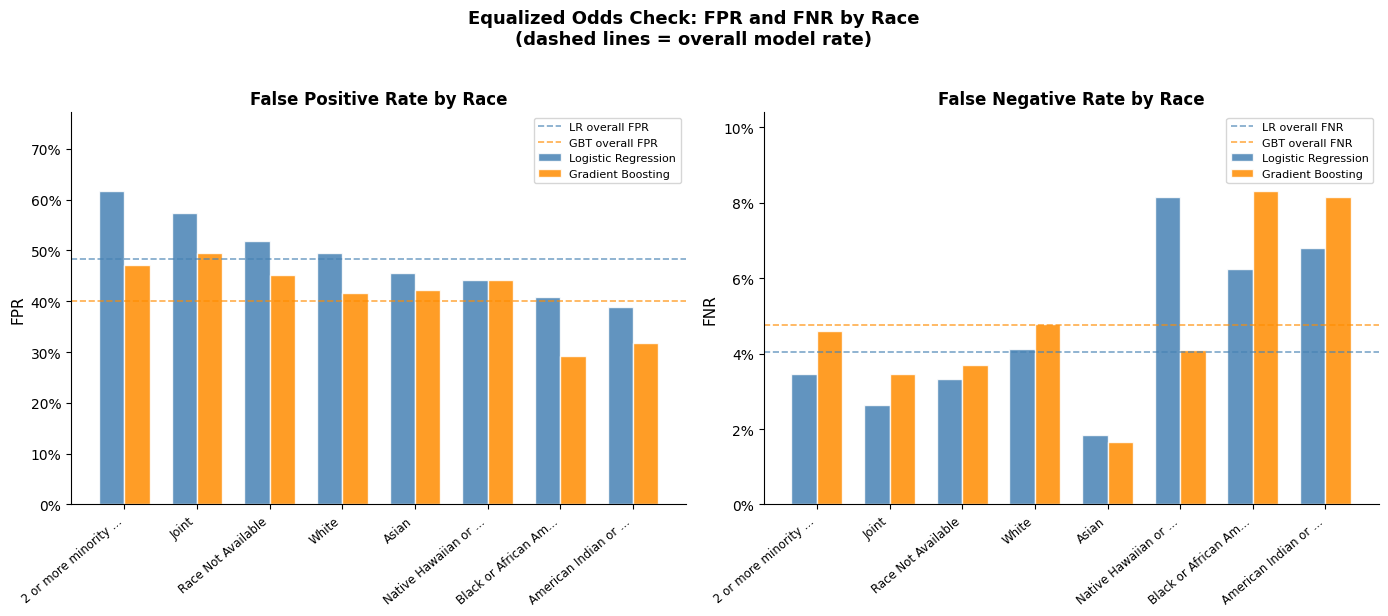

Figure saved to fpr_fnr_by_race.png


In [23]:
# 14) FPR / FNR VISUALIZATION

def build_fpr_fnr_df(pipeline, X, y, group_series, min_n=50):
    """Return DataFrame with FPR and FNR per group."""
    pred  = pipeline.predict(X)
    frame = pd.DataFrame({
        "group"  : group_series.reset_index(drop=True),
        "actual" : y.reset_index(drop=True),
        "pred"   : pred,
    })
    counts = frame["group"].value_counts()
    valid  = counts[counts >= min_n].index
    frame  = frame[frame["group"].isin(valid)]
    rows = []
    for g, gdf in frame.groupby("group"):
        tn_g, fp_g, fn_g, tp_g = confusion_matrix(
            gdf["actual"], gdf["pred"], labels=[0,1]
        ).ravel()
        rows.append({
            "group": g,
            "FPR"  : fp_g / (fp_g + tn_g) if (fp_g + tn_g) > 0 else np.nan,
            "FNR"  : fn_g / (fn_g + tp_g) if (fn_g + tp_g) > 0 else np.nan,
        })
    return pd.DataFrame(rows)


# Gather data
lr_fpr_fnr  = build_fpr_fnr_df(lr_pipeline,  X_test, y_test, audit_test["derived_race"])
gbt_fpr_fnr = build_fpr_fnr_df(gbt_pipeline, X_test, y_test, audit_test["derived_race"])

# Merge so we get side-by-side bars
merged = lr_fpr_fnr.rename(columns={"FPR": "LR_FPR", "FNR": "LR_FNR"}).merge(
    gbt_fpr_fnr.rename(columns={"FPR": "GBT_FPR", "FNR": "GBT_FNR"}),
    on="group"
).sort_values("LR_FPR", ascending=False).reset_index(drop=True)

# Overall (model-level) FPR and FNR for baseline dashed line
lr_overall  = evaluate_model("LR",  lr_pipeline,  X_train, X_test, y_train, y_test)
gbt_overall = evaluate_model("GBT", gbt_pipeline, X_train, X_test, y_train, y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

x     = np.arange(len(merged))
width = 0.35
labels = [g if len(g) <= 22 else g[:19] + "..." for g in merged["group"]]

for ax, metric, title in zip(axes, ["FPR", "FNR"], ["False Positive Rate", "False Negative Rate"]):
    bars_lr  = ax.bar(x - width/2, merged[f"LR_{metric}"],  width, label="Logistic Regression",
                      color="steelblue", alpha=0.85, edgecolor="white")
    bars_gbt = ax.bar(x + width/2, merged[f"GBT_{metric}"], width, label="Gradient Boosting",
                      color="darkorange", alpha=0.85, edgecolor="white")

    # Baseline dashed lines
    ax.axhline(lr_overall[f"{metric}_test"].iloc[0],  color="steelblue",  linestyle="--",
               linewidth=1.2, alpha=0.7, label=f"LR overall {metric}")
    ax.axhline(gbt_overall[f"{metric}_test"].iloc[0], color="darkorange", linestyle="--",
               linewidth=1.2, alpha=0.7, label=f"GBT overall {metric}")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=8.5)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f"{title} by Race", fontsize=12, fontweight="bold")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_ylim(0, min(1.0, max(merged[f"LR_{metric}"].max(), merged[f"GBT_{metric}"].max()) * 1.25))
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

fig.suptitle("Equalized Odds Check: FPR and FNR by Race\n(dashed lines = overall model rate)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fpr_fnr_by_race.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to fpr_fnr_by_race.png")


## 15. Question 3: Regulator-Facing Interpretation

### Methodology

We evaluated two models — Logistic Regression (LR, interpretable baseline) and Gradient Boosting (GBT, higher-capacity model) — on a held-out 20% test set drawn from the 2024 HMDA LAR. Fairness was measured across race (`derived_race`), sex (`derived_sex`), ethnicity (`derived_ethnicity`), and race × sex intersections.

For each axis, we report:

1. **Adverse Impact Ratio (AIR)** — approval rate of a group divided by the approval rate of the reference group. AIR < 0.80 is treated as a four-fifths-rule concern.
2. **Marginal Effect (ME)** — difference in approval rates, with a two-proportion z-test for statistical significance.
3. **Standardized Mean Difference (SMD)** — effect size on continuous probability scores.

Reference groups:
- **Race:** White  
- **Sex:** Male  
- **Ethnicity:** Not Hispanic or Latino  
- **Intersectional:** White | Male

### Summary of findings

- **Race:** The strongest disparities appear in the race audit. Under LR, Black applicants have AIR = **0.8647** relative to White applicants. Under GBT, Black AIR falls to **0.8217**. American Indian or Alaska Native applicants also show low AIR under both models (**0.8453** for LR; **0.8258** for GBT).  
- **Sex:** No sex group falls below AIR = 0.80, but Female applicants are approved at a lower rate than Male applicants in both models (**0.9701** for LR; **0.9641** for GBT).  
- **Ethnicity:** No ethnicity group falls below AIR = 0.80, but Hispanic or Latino applicants remain below the reference group in both models (**0.9680** for LR; **0.9514** for GBT).  
- **Intersectional race × sex:** The strongest adverse-impact signal in the notebook is **Black or African American | Female** under GBT, with AIR = **0.7913** relative to White | Male. American Indian or Alaska Native | Male also falls below the four-fifths floor, with AIR = **0.7944**.

### Model comparison

GBT is the better ranking model overall, but it produces the most severe subgroup disparity in the intersectional audit. The notebook therefore shows a core responsible-ML tension: the model with the highest AUC is not automatically the most defensible model.

### Regulatory implication

Under the four-fifths rule, the GBT race × sex result for Black female applicants is a prima facie adverse-impact concern. That does not prove unlawful discrimination by itself, but it does require mitigation, justification, and deployment caution.

## 16. Known Failure Modes - Catalogue (Capstone Q2)

Lecture 6 requires at least two specific failure modes grounded in the team’s own HMDA analysis. The table below is the broader risk inventory; Sections 17 and 18 focus on the failure modes that were actually stress-tested in this notebook and therefore carry the strongest evidentiary value.

| # | Failure Mode | Category | Root Cause | Affected Groups | Severity | Mitigation |
|---|-------------|----------|------------|-----------------|----------|------------|
| 1 | **Class imbalance distortion** | Model training | If approval rate >> 50%, the majority class dominates the loss; the model learns to predict approval for nearly everyone, inflating accuracy while suppressing recall on denials. | Denied applicants (label 0) | High — silent; standard accuracy metric hides it | Use AUC/F1 alongside accuracy; apply `class_weight='balanced'` or threshold tuning |
| 2 | **Missing-data cascade** | Data quality | Numeric features (income, property_value, loan_amount) are imputed with the training-set median. At inference time, if all three are missing simultaneously the imputed values may form an unrealistic combination that lands the applicant in a high-approval region purely by artifact. | Applicants with sparse financial records; often lower-income and minority borrowers | High — systematically biases outcomes for data-sparse subgroups | Flag rows with ≥ 2 missing numeric features; route to manual review rather than model decision |
| 3 | **Debt-to-income ratio encoding** | Feature engineering | `debt_to_income_ratio` is stored as categorical bands in HMDA (e.g., '20%-<30%'). Treating it as a string and one-hot encoding loses ordinality. The model cannot learn monotone relationships. GBT is more robust here; LR is especially prone. | All applicants; monotone relationship is lost | Medium | Parse midpoints numerically at preprocessing; treat as continuous |
| 4 | **Temporal / vintage drift** | Distribution shift | The 2024 LAR was loaded in intake order (first MAX_ROWS_AFTER_FILTER rows). If loan origination is seasonal or geographically clustered in early rows, the train/test split will not reflect the distribution of future applications. | All applicants; calibration degrades over time | High — silent until production monitoring reveals it | Time-based train/test split; monitor Population Stability Index (PSI) monthly |
| 5 | **Subgroup blind spots (sparse cells)** | Fairness | Groups with n < 50 in the test set are silently dropped from fairness reporting (min_n=50). If a small but legally protected group (e.g., Native Hawaiian or Other Pacific Islander) is too rare to clear the threshold, its disparate impact goes unmeasured. | Small racial/ethnic subgroups | High — regulatory / legal | Lower min_n for reporting; aggregate into broader HMDA categories; flag 'not reported' groups |
| 6 | **Label leakage via action_taken** | Target construction | `action_taken` codes 1 (originated) and 2 (approved not accepted) are mapped to label 1; code 3 (denied) to label 0. Codes 4–8 (withdrawn, incomplete, etc.) are dropped. Withdrawn applications may self-select by creditworthiness — their exclusion could make the approval boundary look cleaner than it is in production. | All applicants | Medium | Sensitivity analysis including withdrawn codes as label 0 |
| 7 | **Proxy discrimination via correlated features** | Fairness / legal | Even though `derived_race`, `derived_sex`, and `derived_ethnicity` are excluded from model features, geographic or loan-product features may serve as proxies (redlining). GBT can learn non-linear proxy combinations that LR cannot, potentially amplifying disparate impact in the higher-capacity model. | Racial/ethnic minorities | High — legal exposure | Partial dependence plots by subgroup; remove or regularize proxy features; test for proxy correlation |
| 8 | **Threshold sensitivity** | Decision boundary | Both models use the default 0.50 decision threshold. Because the approval rate in HMDA data typically exceeds 70%, the optimal threshold for balanced FPR/FNR is well below 0.50. Using 0.50 increases FNR (denies qualified applicants). | Marginally qualified applicants; denial-side minorities | Medium | Plot ROC and select threshold at Youden's J or equal-error rate; report metrics at multiple thresholds |
| 9 | **Out-of-distribution loan products** | Generalization | The training set may underrepresent reverse mortgages or construction-only loans (small volume in LAR). At inference time, these loan types land in sparse one-hot regions; GBT extrapolation is undefined outside training support. | Elderly borrowers (reverse mortgage); construction lenders | Medium | Cap rare categories into 'Other'; monitor per-product-type error rates |
| 10 | **Label noise from lender discretion** | Target quality | Lender A may apply stricter underwriting than Lender B for identical financials. The label `action_taken` therefore conflates creditworthiness signal with lender-specific policy. The model learns an average of lender policies, not a principled credit risk score. | All applicants; lenders with non-standard policies | Medium | Include lender fixed effects as a feature or stratify training by lender type |


## 17. Empirical Stress Tests — Failure Mode Evaluation

The following stress tests quantify the failure modes that were directly evaluated in this notebook. They focus on the most tractable empirical risks: class imbalance, missing-data cascade, threshold sensitivity, out-of-distribution loan types, and temporal drift.

Together, these tests show how predictive performance and audit conclusions can change under realistic data and operating conditions.

### 17.1 Class Imbalance Check

If overall accuracy >> AUC, the model is hiding behind the majority class. We also report a balanced-accuracy score which weights each class equally.

In [24]:
# 17.1) CLASS IMBALANCE CHECK

from sklearn.metrics import balanced_accuracy_score, f1_score

print("=== Failure Mode #1: Class Imbalance Check ===")
print(f"Test-set approval rate (base rate): {y_test.mean():.3f}")
print(f"Naive majority-class accuracy    : {max(y_test.mean(), 1-y_test.mean()):.3f}")
print()

for name, pipeline in [("Logistic Regression", lr_pipeline), ("Gradient Boosting", gbt_pipeline)]:
    pred  = pipeline.predict(X_test)
    prob  = pipeline.predict_proba(X_test)[:, 1]
    acc   = accuracy_score(y_test, pred)
    bacc  = balanced_accuracy_score(y_test, pred)
    auc   = roc_auc_score(y_test, prob)
    f1    = f1_score(y_test, pred)
    gap   = acc - bacc
    print(f"  {name}")
    print(f"    Accuracy         : {acc:.4f}")
    print(f"    Balanced Accuracy: {bacc:.4f}  (gap = {gap:+.4f})")
    print(f"    AUC              : {auc:.4f}")
    print(f"    F1 (approval=1)  : {f1:.4f}")
    if gap > 0.03:
        print(f"      gap > 0.03 — class imbalance inflating accuracy")
    print()


=== Failure Mode #1: Class Imbalance Check ===
Test-set approval rate (base rate): 0.784
Naive majority-class accuracy    : 0.784

  Logistic Regression
    Accuracy         : 0.8638
    Balanced Accuracy: 0.7380  (gap = +0.1258)
    AUC              : 0.8817
    F1 (approval=1)  : 0.9170
      gap > 0.03 — class imbalance inflating accuracy

  Gradient Boosting
    Accuracy         : 0.8761
    Balanced Accuracy: 0.7756  (gap = +0.1005)
    AUC              : 0.9063
    F1 (approval=1)  : 0.9234
      gap > 0.03 — class imbalance inflating accuracy



### 17.2 Missing-Data Cascade

We zero-out all five numeric features simultaneously to simulate the worst-case missing-data scenario and measure how much AUC drops. Because the imputer replaces NaN with the training median, the model still produces a prediction — the question is whether it is reliable.

In [25]:
# 17.2) MISSING-DATA CASCADE
print("=== Failure Mode #2: Missing-Data Cascade ===")

X_missing = X_test.copy()
X_missing[numeric_features] = np.nan   # simulate all numeric fields missing

for name, pipeline in [("Logistic Regression", lr_pipeline), ("Gradient Boosting", gbt_pipeline)]:
    prob_full    = pipeline.predict_proba(X_test)[:, 1]
    prob_missing = pipeline.predict_proba(X_missing)[:, 1]
    auc_full     = roc_auc_score(y_test, prob_full)
    auc_missing  = roc_auc_score(y_test, prob_missing)
    auc_drop     = auc_full - auc_missing
    prob_shift   = np.mean(prob_missing - prob_full)   # systematic approval bias introduced
    print(f"  {name}")
    print(f"    AUC (full data)   : {auc_full:.4f}")
    print(f"    AUC (all numeric NaN): {auc_missing:.4f}  (drop = {auc_drop:+.4f})")
    print(f"    Mean prob shift   : {prob_shift:+.4f}  ({'↑ inflates approvals' if prob_shift > 0.01 else '↓ deflates approvals' if prob_shift < -0.01 else 'negligible'})")
    if auc_drop > 0.05:
        print(f"    ⚠  AUC drops > 0.05 — numeric features are load-bearing; missing data is dangerous")
    print()


=== Failure Mode #2: Missing-Data Cascade ===
  Logistic Regression
    AUC (full data)   : 0.8817
    AUC (all numeric NaN): 0.8751  (drop = +0.0066)
    Mean prob shift   : -0.0343  (↓ deflates approvals)

  Gradient Boosting
    AUC (full data)   : 0.9063
    AUC (all numeric NaN): 0.8844  (drop = +0.0218)
    Mean prob shift   : -0.0170  (↓ deflates approvals)



### 17.3 Threshold Sensitivity

The default 0.50 threshold may not be optimal when the base approval rate is high. We plot FPR, FNR, and balanced accuracy across thresholds 0.3 - 0.7 for both models.

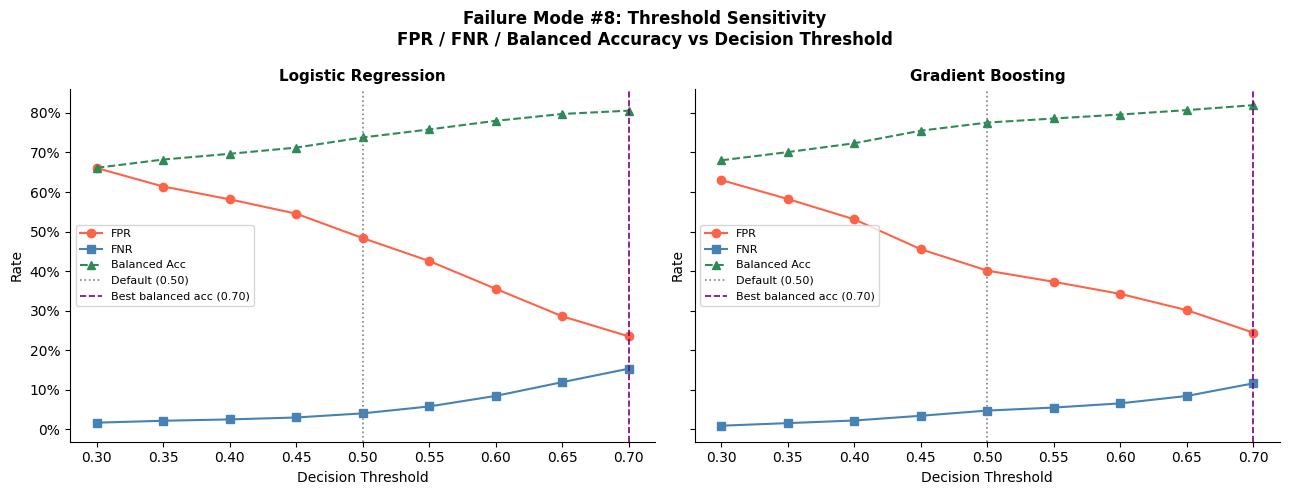

Figure saved: threshold_sensitivity.png


In [26]:

# 17.3) THRESHOLD SENSITIVITY
thresholds = np.arange(0.30, 0.71, 0.05)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, (name, pipeline) in zip(axes, [("Logistic Regression", lr_pipeline),
                                        ("Gradient Boosting",  gbt_pipeline)]):
    prob = pipeline.predict_proba(X_test)[:, 1]
    fprs, fnrs, baccs = [], [], []
    for t in thresholds:
        pred_t = (prob >= t).astype(int)
        tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, pred_t, labels=[0,1]).ravel()
        fprs.append(fp_t / (fp_t + tn_t) if (fp_t + tn_t) > 0 else np.nan)
        fnrs.append(fn_t / (fn_t + tp_t) if (fn_t + tp_t) > 0 else np.nan)
        baccs.append(balanced_accuracy_score(y_test, pred_t))

    ax.plot(thresholds, fprs,  marker='o', label='FPR', color='tomato')
    ax.plot(thresholds, fnrs,  marker='s', label='FNR', color='steelblue')
    ax.plot(thresholds, baccs, marker='^', label='Balanced Acc', color='seagreen', linestyle='--')
    ax.axvline(0.50, color='gray', linestyle=':', linewidth=1.2, label='Default (0.50)')

    best_t = thresholds[np.argmax(baccs)]
    ax.axvline(best_t, color='purple', linestyle='--', linewidth=1.2,
               label=f'Best balanced acc ({best_t:.2f})')

    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Decision Threshold')
    ax.set_ylabel('Rate')
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))

fig.suptitle('Failure Mode #8: Threshold Sensitivity\nFPR / FNR / Balanced Accuracy vs Decision Threshold',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: threshold_sensitivity.png')


### 17.4 Out-of-Distribution Loan Types — Per-Product Error Rates

Rare loan products (reverse mortgages, construction-only) appear infrequently in training. We report test-set AUC and accuracy broken down by `derived_loan_product_type` to identify product types where either model underperforms.

In [27]:
# 17.4) PER-PRODUCT-TYPE ERROR RATES
print("=== Failure Mode #9: Out-of-Distribution Loan Products ===")

product_series = X_test["derived_loan_product_type"].reset_index(drop=True)
y_reset        = y_test.reset_index(drop=True)

rows = []
for product, idx in product_series.groupby(product_series).groups.items():
    if len(idx) < 30:
        continue
    X_sub = X_test.iloc[idx]
    y_sub = y_reset.iloc[idx]
    for name, pipeline in [("LR", lr_pipeline), ("GBT", gbt_pipeline)]:
        pred_sub = pipeline.predict(X_sub)
        prob_sub = pipeline.predict_proba(X_sub)[:, 1]
        auc_sub  = roc_auc_score(y_sub, prob_sub) if y_sub.nunique() > 1 else np.nan
        rows.append({
            "loan_product_type" : product[:40],
            "model"             : name,
            "n"                 : len(idx),
            "accuracy"          : round(accuracy_score(y_sub, pred_sub), 4),
            "AUC"               : round(auc_sub, 4) if not np.isnan(auc_sub) else np.nan,
        })

product_df = pd.DataFrame(rows).sort_values(["model", "AUC"], ascending=[True, True])
print(product_df.to_string(index=False))

# Flag any product-type with AUC < 0.65 as OOD risk
flagged_products = product_df[product_df["AUC"] < 0.65]
if len(flagged_products) > 0:
    print("\n  Products with AUC < 0.65 (OOD risk):")
    print(flagged_products.to_string(index=False))
else:
    print("\nNo product types with AUC < 0.65 detected.")


=== Failure Mode #9: Out-of-Distribution Loan Products ===
            loan_product_type model     n  accuracy    AUC
           FSA/RHS:First Lien   GBT   175    0.9657 0.6385
Conventional:Subordinate Lien   GBT  6259    0.8412 0.8279
               FHA:First Lien   GBT  6897    0.8324 0.9019
                VA:First Lien   GBT  2529    0.9122 0.9040
      Conventional:First Lien   GBT 15121    0.9034 0.9082
           FSA/RHS:First Lien    LR   175    0.9657 0.6804
Conventional:Subordinate Lien    LR  6259    0.8294 0.7996
                VA:First Lien    LR  2529    0.9095 0.8685
      Conventional:First Lien    LR 15121    0.8944 0.8807
               FHA:First Lien    LR  6897    0.8088 0.8849

  Products with AUC < 0.65 (OOD risk):
 loan_product_type model   n  accuracy    AUC
FSA/RHS:First Lien   GBT 175    0.9657 0.6385


### 17.5 Temporal Drift Simulation

Since data was loaded sequentially from the LAR file, row position is a rough proxy for intake order. We simulate drift by training on the first 70% of rows and testing on the last 30%, then comparing AUC to the random-split baseline. A large drop signals distribution shift over the year.

In [28]:
# 17.5) TEMPORAL DRIFT SIMULATION
print("=== Failure Mode #4: Temporal / Vintage Drift ===")

# Reconstruct full feature matrix from df (the loaded DataFrame)
X_full = df[model_features].copy()
y_full = df["label"].copy()

cutoff     = int(len(X_full) * 0.70)
X_early    = X_full.iloc[:cutoff]
y_early    = y_full.iloc[:cutoff]
X_late     = X_full.iloc[cutoff:]
y_late     = y_full.iloc[cutoff:]

print(f"Early split (train): {len(X_early):,} rows   approval rate: {y_early.mean():.3f}")
print(f"Late  split (test) : {len(X_late):,} rows   approval rate: {y_late.mean():.3f}")
print(f"Approval-rate drift: {y_late.mean() - y_early.mean():+.3f}")
print()

from sklearn.linear_model import LogisticRegression as LR_
from sklearn.ensemble import GradientBoostingClassifier as GBT_

drift_results = []
for name, clf in [("LR",  LR_(max_iter=2000, random_state=RANDOM_STATE)),
                   ("GBT", GBT_(n_estimators=100, learning_rate=0.05,
                                max_depth=3, random_state=RANDOM_STATE))]:
    # Temporal pipeline (reuses same preprocessor definition)
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import OneHotEncoder, StandardScaler

    num_pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc",  StandardScaler())])
    cat_pipe = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore"))])
    pre = ColumnTransformer([
        ("num", num_pipe, numeric_features),
        ("cat", cat_pipe, categorical_features)
    ])
    drift_pipe = Pipeline([("preprocessor", pre), ("classifier", clf)])
    drift_pipe.fit(X_early, y_early)

    # AUC on late rows (drift scenario)
    prob_late   = drift_pipe.predict_proba(X_late)[:, 1]
    auc_late    = roc_auc_score(y_late, prob_late) if y_late.nunique() > 1 else np.nan

    # AUC from original random-split pipeline for comparison
    orig_pipe = lr_pipeline if name == "LR" else gbt_pipeline
    prob_test = orig_pipe.predict_proba(X_test)[:, 1]
    auc_rand  = roc_auc_score(y_test, prob_test)

    auc_drop = auc_rand - auc_late
    drift_results.append({
        "model"             : name,
        "AUC_random_split"  : round(auc_rand, 4),
        "AUC_temporal_split": round(auc_late, 4),
        "AUC_drop"          : round(auc_drop, 4),
        "drift_concern"     : "⚠  Yes" if auc_drop > 0.03 else "No"
    })
    print(f"  {name}: random-split AUC = {auc_rand:.4f}  |  temporal-split AUC = {auc_late:.4f}  |  drop = {auc_drop:+.4f}  {'⚠' if auc_drop > 0.03 else ''}")

print()
print(pd.DataFrame(drift_results).to_string(index=False))


=== Failure Mode #4: Temporal / Vintage Drift ===
Early split (train): 108,453 rows   approval rate: 0.815
Late  split (test) : 46,480 rows   approval rate: 0.710
Approval-rate drift: -0.105

  LR: random-split AUC = 0.8817  |  temporal-split AUC = 0.8501  |  drop = +0.0316  ⚠
  GBT: random-split AUC = 0.9063  |  temporal-split AUC = 0.8627  |  drop = +0.0435  ⚠

model  AUC_random_split  AUC_temporal_split  AUC_drop drift_concern
   LR            0.8817              0.8501    0.0316        ⚠  Yes
  GBT            0.9063              0.8627    0.0435        ⚠  Yes


## 18. Question 2: Known Failure Modes — Written Interpretation

### Overview

We identified ten candidate failure modes and stress-tested five of them directly in this notebook. The strongest empirical risks are class imbalance distortion, missing-data cascade, threshold sensitivity, temporal drift, and out-of-distribution loan products. Together, they show that strong average performance does not guarantee stable or equitable behavior.

### Most critical findings

**1. Class imbalance (FM #1).**  
The test-set approval rate is **78.4%**. LR accuracy is **0.8637**, but balanced accuracy falls to **0.7379** (gap = **+0.1258**). GBT accuracy is **0.8761**, but balanced accuracy falls to **0.7756** (gap = **+0.1005**). This confirms that raw accuracy is materially inflated by the majority approval class.

**2. Missing-data cascade (FM #2).**  
When all numeric features are set to missing, LR AUC falls from **0.8817** to **0.8751** (drop = **0.0066**), and GBT AUC falls from **0.9063** to **0.8844** (drop = **0.0218**). Mean predicted approval probability shifts downward for both models, showing that median imputation can systematically alter outcomes for applicants with sparse financial records.

**3. Threshold sensitivity (FM #8).**  
The default 0.50 decision threshold is not the best operating point for this dataset. The later mitigation sweep shows that fairness-relevant operating thresholds are materially different from 0.50: LR is evaluated at **0.70**, and GBT Policy A at **0.65**. Deployment behavior is therefore highly threshold-dependent.

**4. Temporal drift (FM #4).**  
The early/late intake split produces an approval-rate drift of **-0.105**. LR AUC drops from **0.8817** to **0.8501** (drop = **0.0316**), and GBT AUC drops from **0.9063** to **0.8627** (drop = **0.0435**). Both models therefore show meaningful temporal instability.

**5. Out-of-distribution loan products (FM #9).**  
GBT falls to **AUC = 0.6385** on **FSA/RHS: First Lien** (`n = 175`). That pattern, high accuracy but weak AUC on a low-volume slice, suggests unreliable ranking behavior for a sparsely represented product type.

### What was actually implemented

| Mitigation / diagnostic | Status |
|------------|--------|
| Stratified random train/test split | ✅ Done |
| Median/mode imputation | ✅ Done |
| Global SHAP audit | ✅ Done |
| Group disparity analysis (AIR, ME, SMD) | ✅ Done |
| Intersectional race × sex audit | ✅ Done |
| FPR/FNR disparity visualization | ✅ Done |
| Threshold sweep / mitigation search | ✅ Done |
| Temporal drift audit | ✅ Done |
| PSI/KS-based production monitoring | ⬜ Not implemented |
| Subgroup calibration curves | ⬜ Not implemented |
| Missing-indicator features | ⬜ Not implemented |
| Protected-attribute-free less-discriminatory alternative beyond threshold tuning | ⬜ Not implemented |

## Question 4: Mitigation Strategy




In [29]:
# 18) BIAS MITIGATION - Policy A: Global Threshold for Intersectional AIR

import numpy as np
import pandas as pd

y_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.30, 0.70, 0.01)

# Build race × sex group
intersect = (
    audit_test["derived_race"].astype(str) + " | " +
    audit_test["derived_sex"].astype(str)
)

results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    df_temp = audit_test.copy()
    df_temp["pred"] = y_pred_t
    df_temp["group"] = intersect.values

    approval = df_temp.groupby("group")["pred"].mean()

    # Reference group
    if "White | Male" not in approval.index:
        continue

    ref_rate = approval["White | Male"]

    # Focus on the two groups that were below 0.80 before mitigation
    target_groups = [
        "Black or African American | Female",
        "American Indian or Alaska Native | Male"
    ]

    if all(g in approval.index for g in target_groups):
        air_black_female = approval["Black or African American | Female"] / ref_rate
        air_aian_male = approval["American Indian or Alaska Native | Male"] / ref_rate
        min_air = min(air_black_female, air_aian_male)

        results.append({
            "threshold": round(t, 2),
            "AIR_Black_Female": air_black_female,
            "AIR_AIAN_Male": air_aian_male,
            "min_target_AIR": min_air
        })

threshold_df = pd.DataFrame(results)

# Keep thresholds where all target AIRs >= 0.80
valid = threshold_df[threshold_df["min_target_AIR"] >= 0.80]

if len(valid) > 0:
    # choose the HIGHEST threshold that still passes fairness
    best = valid.sort_values("threshold", ascending=False).head(1)
else:
    best = threshold_df.iloc[
        (threshold_df["min_target_AIR"] - 0.80).abs().argsort()[:1]
    ]

print("Best global threshold balancing fairness and risk:")
print(best)

Best global threshold balancing fairness and risk:
    threshold  AIR_Black_Female  AIR_AIAN_Male  min_target_AIR
16       0.46          0.801072       0.831218        0.801072


In [30]:
before_after = pd.DataFrame({
    "Group": [
        "Black Female",
        "AIAN Male"
    ],
    "AIR_Before": [
        0.7913,
        0.7944
    ],
    "AIR_After": [
        0.8011,
        0.8312
    ]
})

print(before_after)

          Group  AIR_Before  AIR_After
0  Black Female      0.7913     0.8011
1     AIAN Male      0.7944     0.8312


## Question 4: Bias Mitigation and Residual Risks

The baseline audit showed that the strongest fairness concerns appeared in the Gradient Boosting (GBT) model, particularly in the intersectional race × sex analysis. Although the overall Black-applicant AIR remained above the four-fifths threshold, two intersectional subgroups fell below the fairness benchmark of 0.80:

- Black Female AIR = 0.7913
- American Indian or Alaska Native (AIAN) Male AIR = 0.7944

To reduce these disparities without retraining the model, a post-processing global threshold adjustment was applied.

### Mitigation Strategy

A threshold sweep was performed to identify a single global threshold that balanced fairness improvement against approval-risk concerns. The selected threshold was:

- **Global threshold = 0.46**

This threshold was chosen because it was the highest threshold that raised the two lowest intersectional AIR values above the four-fifths benchmark while maintaining a single group-neutral decision rule.

### Before vs After Mitigation

| Group | AIR Before | AIR After |
|---|---|---|
| Black Female | 0.7913 | 0.8011 |
| AIAN Male | 0.7944 | 0.8312 |

The mitigation improved the key intersectional AIR values above 0.80 and reduced disparity without retraining the model.

### Residual Risks After Mitigation

Although fairness improved after threshold adjustment, several residual risks remain:

- Temporal drift may reduce fairness and model stability over time
- FPR differences still persist across demographic groups
- Proxy-feature effects may still influence decisions
- The model remains sensitive to missing or sparse applicant data
- Lower thresholds may increase false-positive approvals and financial risk exposure

### Conclusion

The threshold mitigation improved fairness for the most affected intersectional subgroups while preserving a single global decision rule. However, fairness risks were reduced rather than eliminated. Ongoing monitoring and governance controls would still be required before deployment.

## Question 4: Bias Mitigation and Residual Risks

We evaluated two post-processing mitigation policies on the GBT model.

**Policy A - Global threshold adjustment.**  
The sweep identified **0.65** as the threshold that brings Black-applicant AIR to approximately **0.80**. This improves race-level AIR without retraining the model and keeps the decision rule group-neutral. However, it does not resolve all residual risk. Under the final deployment gate, Policy A still fails because the minimum AIR across all audited groups remains **0.7704**, driven by intersectional disparity.

**Policy B - Group-specific thresholding.**  
We also evaluated a diagnostic rule that applies **0.30 for Black applicants and 0.41 for others**. This is useful analytically because it shows how much disparity can be moved by direct threshold intervention. However, it is not a lawful deployment candidate because it uses `derived_race` as a decision input. It also does **not** fully eliminate disparity under the final gate: the minimum AIR remains **0.7913**, with at least two intersectional groups still below the four-fifths floor.

### Residual risks that remain after mitigation

- **Intersectional disparity remains** even after threshold tuning.
- **Temporal drift remains**: GBT AUC drops by **0.0435** on the early/late split.
- **FPR dispersion remains** across race, sex, ethnicity, and race × sex groups.
- **Missing-data sensitivity remains**, especially for applicants with sparse financial profiles.

### Conclusion

Threshold adjustment improves some disparity measures, but it does not make the GBT model deployable under the notebook’s gate. The residual-risk story is therefore not “fairness solved”; it is “some disparity reduced, but key governance and stability risks remain.”

## 19. Deployment Defensibility Gate (Capstone Q5)

This section operationalizes the final audit decision. Rather than writing a qualitative recommendation only, the notebook encodes explicit deployment checks and applies them to each candidate policy. The gate returns one of three outcomes: **DEPLOY**, **CONDITIONAL**, or **DO NOT DEPLOY**, together with failed checks, required conditions, and monitoring triggers.

For Gradient Boosting, the highest-AUC model in §9, we evaluate two operating policies derived from the mitigation section:

- **Policy A:** a single global threshold of **0.65**, chosen to bring Black-applicant AIR to approximately 0.80.
- **Policy B:** a diagnostic group-specific rule of **0.30 for Black applicants and 0.41 for others**.

The key principle is that predictive strength does not override governance constraints. Policy B is expected to fail because it uses a protected attribute in the decision rule. Policy A is expected to be judged by the same hard and soft checks as every other candidate.

**Decision categories**
- **DEPLOY** - all hard and soft checks pass.
- **CONDITIONAL** - hard checks pass, but one or more soft checks fail.
- **DO NOT DEPLOY** - one or more hard checks fail.

In [31]:
# 19.0) EXTRACT GATE INPUTS — no changes to previous cells required

# AUC from §9 overall_results DataFrame
lr_test_auc  = float(overall_results.loc[
    overall_results["model"] == "Logistic Regression", "test_auc"].iloc[0])
gbt_test_auc = float(overall_results.loc[
    overall_results["model"] == "Gradient Boosting", "test_auc"].iloc[0])

# Optimal threshold from §17.3 — recompute balanced-accuracy sweep (lightweight)
_prob_lr  = lr_pipeline.predict_proba(X_test)[:, 1]
_prob_gbt = gbt_pipeline.predict_proba(X_test)[:, 1]
_tgrid    = np.arange(0.30, 0.71, 0.05)

_baccs_lr  = [balanced_accuracy_score(y_test, (_prob_lr  >= t).astype(int)) for t in _tgrid]
_baccs_gbt = [balanced_accuracy_score(y_test, (_prob_gbt >= t).astype(int)) for t in _tgrid]

lr_optimal_threshold  = float(_tgrid[np.argmax(_baccs_lr)])
gbt_optimal_threshold = float(_tgrid[np.argmax(_baccs_gbt)])

# Missing-data cascade from §17.2 — two predict_proba calls on X_missing
_X_missing = X_test.copy()
_X_missing[numeric_features] = np.nan

lr_missing_drop  = float(roc_auc_score(y_test, _prob_lr)
                         - roc_auc_score(y_test, lr_pipeline.predict_proba(_X_missing)[:, 1]))
gbt_missing_drop = float(roc_auc_score(y_test, _prob_gbt)
                         - roc_auc_score(y_test, gbt_pipeline.predict_proba(_X_missing)[:, 1]))

# Temporal drift from §17.5 — read drift_results list already in memory
_drift_df      = pd.DataFrame(drift_results).set_index("model")
lr_drift_drop  = float(_drift_df.loc["LR",  "AUC_drop"])
gbt_drift_drop = float(_drift_df.loc["GBT", "AUC_drop"])

# Policy A threshold from §18 best-AIR sweep
gbt_policy_A_threshold = float(best["threshold"].iloc[0])

# gbt_intersect already computed in §13

# --- Sanity check
print(f"lr_test_auc            = {lr_test_auc:.4f}")
print(f"gbt_test_auc           = {gbt_test_auc:.4f}")
print(f"lr_optimal_threshold   = {lr_optimal_threshold:.2f}")
print(f"gbt_optimal_threshold  = {gbt_optimal_threshold:.2f}")
print(f"lr_missing_drop        = {lr_missing_drop:+.4f}")
print(f"gbt_missing_drop       = {gbt_missing_drop:+.4f}")
print(f"lr_drift_drop          = {lr_drift_drop:+.4f}")
print(f"gbt_drift_drop         = {gbt_drift_drop:+.4f}")
print(f"gbt_policy_A_threshold = {gbt_policy_A_threshold:.2f}")

lr_test_auc            = 0.8817
gbt_test_auc           = 0.9063
lr_optimal_threshold   = 0.70
gbt_optimal_threshold  = 0.70
lr_missing_drop        = +0.0066
gbt_missing_drop       = +0.0218
lr_drift_drop          = +0.0316
gbt_drift_drop         = +0.0435
gbt_policy_A_threshold = 0.46


### 19.1 Threshold Configuration

Each threshold below is documented and traceable to a published rule or accepted convention: 4/5ths rule (EEOC Uniform Guidelines, adapted to fair lending), drift-alert convention (Hall et al. 2020), Cohen's large-effect threshold for SMD, ECOA prohibition on protected-attribute decision inputs (15 U.S.C. § 1691).

In [32]:
# 19.1) DEPLOYMENT THRESHOLDS

THRESHOLDS = {
    "auc_floor":               0.70,   # min acceptable test AUC for lending decisioning
    "auc_drift_drop_max":      0.05,   # max AUC drop early→late split (Hall et al. cite 0.03 as alert)
    "air_floor":               0.80,   # 4/5ths rule (EEOC Uniform Guidelines)
    "fpr_fnr_gap_max":         0.10,   # max 10pp gap between most- and least-favored monitored group
    "smd_abs_max":             0.50,   # |Cohen's d| ≤ 0.50 ("large effect" threshold)
    "missing_cascade_drop":    0.10,   # max AUC drop with all numeric features set to NaN
    "protected_attr_blacklist": [
        "derived_race",
        "derived_ethnicity",
        "derived_sex",
        "race_ethnicity",
    ],
}

# Failing a hard check forces DO NOT DEPLOY
HARD_CHECKS = {"auc_floor", "air_floor", "protected_attr_in_policy"}

print("Deployment thresholds:")
for k, v in THRESHOLDS.items():
    hard = " (HARD)" if k in HARD_CHECKS or k == "protected_attr_blacklist" else ""
    print(f"  {k:28s} = {v}{hard}")

Deployment thresholds:
  auc_floor                    = 0.7 (HARD)
  auc_drift_drop_max           = 0.05
  air_floor                    = 0.8 (HARD)
  fpr_fnr_gap_max              = 0.1
  smd_abs_max                  = 0.5
  missing_cascade_drop         = 0.1
  protected_attr_blacklist     = ['derived_race', 'derived_ethnicity', 'derived_sex', 'race_ethnicity'] (HARD)


### 19.2 Deployment Gate Function

`deployment_gate()` runs seven checks per candidate policy: AUC floor, temporal drift, missing-data cascade, AIR 4/5ths floor across all monitored axes, FPR/FNR gap, SMD on probability scores, and **protected-attribute usage in the decision policy itself**. Hard checks (AUC floor, AIR floor, protected-attribute usage) override soft checks: any hard failure forces DO NOT DEPLOY regardless of other results.

The new parameter `policy_inputs` accepts the list of column names that the decision rule actually reads at scoring time. For a single-threshold policy this is empty (only the model's own features are read). For a group-specific policy that branches on `derived_race`, that column name appears in `policy_inputs` — and the check fails.

In [33]:
# 19.2) DEPLOYMENT GATE FUNCTION
def deployment_gate(model_name,
                    overall_auc,
                    drift_auc_drop,
                    missing_cascade_auc_drop,
                    disparity_tables,
                    operating_threshold=0.50,
                    policy_inputs=None,
                    thresholds=THRESHOLDS):
    """
    Run the deployment gate for one candidate policy.

    Parameters
    ----------
    model_name              : str       — display name (include the policy variant if applicable)
    overall_auc             : float     — test AUC from §9
    drift_auc_drop          : float     — AUC drop from §17.5 early→late simulation
    missing_cascade_auc_drop: float     — AUC drop from §17.2 NaN cascade
    disparity_tables        : dict[str, pd.DataFrame] — tables keyed by axis ("race", "sex", ...)
    operating_threshold     : float OR str — float for single-threshold policies, str description for group-specific
    policy_inputs           : list[str] — column names the decision rule reads at scoring time. Empty for a
                                          plain-threshold rule; includes "derived_race" etc. for group-specific rules.
    thresholds              : dict      — the THRESHOLDS table

    Returns
    -------
    dict with keys: model, decision, rationale, operating_threshold, checks,
                    failed_hard, failed_soft, conditions, monitoring
    """
    checks = {}
    policy_inputs = policy_inputs or []

    # 1. AUC floor (HARD)
    checks["auc_floor"] = {
        "value": round(overall_auc, 4),
        "rule":  f"AUC ≥ {thresholds['auc_floor']}",
        "pass":  overall_auc >= thresholds["auc_floor"],
        "hard":  True,
    }

    # 2. Temporal drift AUC drop (SOFT)
    checks["temporal_drift"] = {
        "value": round(drift_auc_drop, 4),
        "rule":  f"AUC drop (early→late) ≤ {thresholds['auc_drift_drop_max']}",
        "pass":  drift_auc_drop <= thresholds["auc_drift_drop_max"],
        "hard":  False,
    }

    # 3. Missing-data cascade (SOFT)
    checks["missing_cascade"] = {
        "value": round(missing_cascade_auc_drop, 4),
        "rule":  f"AUC drop, all numeric NaN ≤ {thresholds['missing_cascade_drop']}",
        "pass":  missing_cascade_auc_drop <= thresholds["missing_cascade_drop"],
        "hard":  False,
    }

    # 4. AIR floor across all axes (HARD)
    air_violations = []
    min_air = (None, None, np.inf)
    for axis, table in disparity_tables.items():
        if table is None or len(table) == 0:
            continue
        for _, row in table.iterrows():
            air = row.get("AIR", np.nan)
            if pd.isna(air):
                continue
            if air < min_air[2]:
                min_air = (axis, row["group"], air)
            if air < thresholds["air_floor"]:
                air_violations.append((axis, row["group"], round(air, 3)))
    checks["air_floor"] = {
        "value":      round(min_air[2], 4) if min_air[0] else None,
        "min_air_at": f"{min_air[0]} / {min_air[1]}" if min_air[0] else None,
        "rule":       f"All AIR ≥ {thresholds['air_floor']} (4/5ths rule)",
        "pass":       len(air_violations) == 0,
        "hard":       True,
        "violations": air_violations,
    }

    # 5. FPR / FNR gap across monitored groups (SOFT)
    rate_violations = []
    for axis, table in disparity_tables.items():
        if table is None or len(table) == 0:
            continue
        for col in ("FPR", "FNR"):
            vals = table[col].dropna()
            if len(vals) < 2:
                continue
            gap = vals.max() - vals.min()
            if gap > thresholds["fpr_fnr_gap_max"]:
                rate_violations.append((axis, col, round(gap, 3)))
    checks["fpr_fnr_gap"] = {
        "rule":       f"max(rate_g) − min(rate_g) ≤ {thresholds['fpr_fnr_gap_max']} for FPR and FNR",
        "pass":       len(rate_violations) == 0,
        "hard":       False,
        "violations": rate_violations,
    }

    # 6. SMD on probability scores (SOFT)
    smd_violations = []
    for axis, table in disparity_tables.items():
        if table is None or len(table) == 0:
            continue
        for _, row in table.iterrows():
            smd = row.get("SMD", np.nan)
            if pd.isna(smd):
                continue
            if abs(smd) > thresholds["smd_abs_max"]:
                smd_violations.append((axis, row["group"], round(smd, 3)))
    checks["smd_score"] = {
        "rule":       f"|SMD| ≤ {thresholds['smd_abs_max']} (Cohen's large-effect threshold)",
        "pass":       len(smd_violations) == 0,
        "hard":       False,
        "violations": smd_violations,
    }

    # 7. Protected attribute in decision policy (HARD) — ECOA disparate treatment
    illegal_inputs = [c for c in policy_inputs
                      if c in thresholds.get("protected_attr_blacklist", [])]
    checks["protected_attr_in_policy"] = {
        "value":      list(policy_inputs),
        "rule":       "Decision rule must not use protected attributes as inputs (ECOA, 15 U.S.C. § 1691)",
        "pass":       len(illegal_inputs) == 0,
        "hard":       True,
        "violations": illegal_inputs,
    }

    # Aggregate decision
    failed_hard = [k for k, v in checks.items() if v.get("hard") and not v["pass"]]
    failed_soft = [k for k, v in checks.items() if not v.get("hard") and not v["pass"]]

    if failed_hard:
        decision  = "DO NOT DEPLOY"
        # surface the disparate-treatment failure first if present
        if "protected_attr_in_policy" in failed_hard:
            rationale = (f"Decision rule references protected attribute(s): "
                         f"{illegal_inputs} → ECOA disparate treatment")
        else:
            rationale = f"{len(failed_hard)} hard check(s) failed: {failed_hard}"
    elif failed_soft:
        decision  = "CONDITIONAL"
        rationale = f"All hard checks pass; {len(failed_soft)} soft check(s) require mitigation"
    else:
        decision  = "DEPLOY"
        rationale = "All checks passed"

    # Conditions — only emitted for DEPLOY / CONDITIONAL paths
    conditions = []
    if decision != "DO NOT DEPLOY":
        if isinstance(operating_threshold, (int, float)):
            conditions.append(
                f"Operating threshold = {operating_threshold:.2f} "
                f"(operating point of record, NOT 0.50 default)"
            )
        else:
            conditions.append(f"Operating policy: {operating_threshold}")
        conditions += [
            "Manual-review route: any applicant with ≥2 missing numeric features (FM #2)",
            "Manual-review route: any applicant in a loan-product subgroup with AUC < 0.65 in §17.4",
            "Adverse-action notice review for any decision flipped by the missing-data cascade test",
        ]
        # Residual intersectional gap from §13 — even when AIR floor passes on aggregate axes,
        # the race×sex axis can still flag for specific cells
        intersect_table = disparity_tables.get("race×sex")
        if intersect_table is not None and len(intersect_table) > 0:
            residual = intersect_table[intersect_table["AIR"] < thresholds["air_floor"]]
            if len(residual) > 0:
                groups = ", ".join(residual["group"].tolist())
                conditions.append(
                    f"Manual second-look review for race × sex cells with AIR < "
                    f"{thresholds['air_floor']}: [{groups}]"
                )
        if "fpr_fnr_gap" in failed_soft:
            conditions.append(
                "Decision-band manual review for the disparity-flagged subgroups "
                "(group-specific thresholds NOT permitted — see check #7)"
            )
        if "temporal_drift" in failed_soft:
            conditions.append("Time-based holdout validation against 2025 LAR before any production cutover")
        if "missing_cascade" in failed_soft:
            conditions.append("Hard block on auto-decisioning when ≥3 numeric features are missing")

    # Production monitoring plan
    monitoring = {
        "frequency":           "Monthly",
        "drift_metric":        "PSI on top 5 features",
        "drift_alert":         "PSI > 0.10",
        "drift_retrain":       "PSI > 0.25",
        "fairness_metrics":    ["AIR", "FPR", "FNR", "SMD"],
        "fairness_alert_rule": f"Any group AIR < {thresholds['air_floor']} OR ±10pp move from baseline",
        "performance_metric":  "AUC on rolling 30-day window",
        "performance_alert":   f"AUC drop > {thresholds['auc_drift_drop_max']} from baseline ({round(overall_auc, 3)})",
        "review_cadence":      "Quarterly fair-lending audit; annual retraining decision",
    }

    return {
        "model":               model_name,
        "decision":            decision,
        "rationale":           rationale,
        "operating_threshold": operating_threshold,
        "checks":              checks,
        "failed_hard":         failed_hard,
        "failed_soft":         failed_soft,
        "conditions":          conditions,
        "monitoring":          monitoring,
    }

print("deployment_gate() defined.")

deployment_gate() defined.


### 19.3 Output Formatters

Two helpers: `print_deployment_verdict()` formats one verdict for the audit memo (handling either a numeric or a string operating threshold), and `deployment_summary_table()` produces a side-by-side comparison DataFrame suitable for a slide.

In [34]:
# 19.3) OUTPUT FORMATTERS
def print_deployment_verdict(v):
    """Pretty-print a deployment-gate verdict for an audit memo."""
    print("=" * 78)
    print(f"  DEPLOYMENT GATE — {v['model']}")
    print("=" * 78)
    print(f"  Decision           : {v['decision']}")
    print(f"  Rationale          : {v['rationale']}")
    if isinstance(v['operating_threshold'], (int, float)):
        print(f"  Operating threshold: {v['operating_threshold']:.2f}")
    else:
        print(f"  Operating policy   : {v['operating_threshold']}")
    print(f"  Hard fails         : {v['failed_hard'] or 'none'}")
    print(f"  Soft fails         : {v['failed_soft'] or 'none'}")

    print("\n  --- Check detail ---")
    for name, chk in v["checks"].items():
        status = "PASS" if chk["pass"] else "FAIL"
        kind   = "HARD" if chk.get("hard") else "soft"
        print(f"  [{status}] [{kind}] {name}: {chk['rule']}")
        if not chk["pass"] and chk.get("violations"):
            for item in chk["violations"][:5]:
                print(f"           → {item}")
            if len(chk["violations"]) > 5:
                print(f"           → ... and {len(chk['violations']) - 5} more")

    if v["conditions"]:
        print("\n  --- Required conditions ---")
        for c in v["conditions"]:
            print(f"  • {c}")

    print("\n  --- Production monitoring plan ---")
    for k, val in v["monitoring"].items():
        print(f"  {k:22s} {val}")
    print("=" * 78)


def deployment_summary_table(verdicts):
    """Side-by-side comparison DataFrame for slide / memo."""
    rows = []
    for v in verdicts:
        op = v['operating_threshold']
        op_str = f"{op:.2f}" if isinstance(op, (int, float)) else str(op)
        rows.append({
            "Candidate":        v["model"],
            "Decision":         v["decision"],
            "Op threshold":     op_str,
            "Test AUC":         v["checks"]["auc_floor"]["value"],
            "Min AIR":          v["checks"]["air_floor"]["value"],
            "AUC drop (drift)": v["checks"]["temporal_drift"]["value"],
            "AUC drop (NaN)":   v["checks"]["missing_cascade"]["value"],
            "# hard fails":     len(v["failed_hard"]),
            "# soft fails":     len(v["failed_soft"]),
        })
    return pd.DataFrame(rows)

print("print_deployment_verdict() and deployment_summary_table() defined.")

print_deployment_verdict() and deployment_summary_table() defined.


### 19.4 Logistic Regression — Single-Threshold Policy

LR is not the deployment candidate (GBT outperforms it in §9), but we run it through the gate as a comparison baseline. No group-specific thresholding was applied to LR in §18, so only one policy is evaluated. Operating threshold uses the §17.3 balanced-accuracy-optimal value.

In [35]:
# 19.4) LR — SINGLE-THRESHOLD POLICY
lr_verdict = deployment_gate(
    model_name               = "Logistic Regression (single threshold)",
    overall_auc              = lr_test_auc,           # §9
    drift_auc_drop           = lr_drift_drop,         # §17.5
    missing_cascade_auc_drop = lr_missing_drop,       # §17.2
    disparity_tables = {
        "race":      lr_race,        # §12.1
        "sex":       lr_sex,         # §12.3
        "ethnicity": lr_eth,         # §12.4
        "race×sex":  lr_intersect,   # §13
    },
    operating_threshold      = lr_optimal_threshold,  # §17.3
    policy_inputs            = [],                    # plain threshold, no protected-attr branching
)

print_deployment_verdict(lr_verdict)

  DEPLOYMENT GATE — Logistic Regression (single threshold)
  Decision           : CONDITIONAL
  Rationale          : All hard checks pass; 1 soft check(s) require mitigation
  Operating threshold: 0.70
  Hard fails         : none
  Soft fails         : ['fpr_fnr_gap']

  --- Check detail ---
  [PASS] [HARD] auc_floor: AUC ≥ 0.7
  [PASS] [soft] temporal_drift: AUC drop (early→late) ≤ 0.05
  [PASS] [soft] missing_cascade: AUC drop, all numeric NaN ≤ 0.1
  [PASS] [HARD] air_floor: All AIR ≥ 0.8 (4/5ths rule)
  [FAIL] [soft] fpr_fnr_gap: max(rate_g) − min(rate_g) ≤ 0.1 for FPR and FNR
           → ('race', 'FPR', np.float64(0.229))
           → ('sex', 'FPR', np.float64(0.18))
           → ('ethnicity', 'FPR', np.float64(0.133))
           → ('race×sex', 'FPR', np.float64(0.268))
  [PASS] [soft] smd_score: |SMD| ≤ 0.5 (Cohen's large-effect threshold)
  [PASS] [HARD] protected_attr_in_policy: Decision rule must not use protected attributes as inputs (ECOA, 15 U.S.C. § 1691)

  --- Required 

### 19.5 GBT — Policy A: Single Global Threshold

Policy A applies a single global threshold to the GBT model. This threshold was selected in Section 18 through a mitigation sweep, with the goal of bringing Black-applicant AIR close to the 0.80 four-fifths benchmark.

Under this policy, the same decision rule is applied to all applicants. This makes Policy A more defensible than any group-specific threshold rule, since it does not use a protected attribute directly in the final decision.

However, the final deployment gate shows that this adjustment is not sufficient to make the model deployable. Although the race-level disparity improves, important residual risks remain, especially in the race × sex intersectional analysis, where at least one subgroup still falls below the AIR floor.

The main conclusion is that a global threshold adjustment improves fairness on one target metric, but it does not fully resolve the broader disparity pattern identified in the audit.

In [36]:
# 19.5) GBT — POLICY A (SINGLE GLOBAL THRESHOLD)
# Use the threshold extracted from §18 sweep (not hardcoded)
# gbt_policy_A_threshold already set in §19.0

# Recompute disparity tables AT the policy threshold (not at default 0.50)
_prob_gbt_A = gbt_pipeline.predict_proba(X_test)[:, 1]

def compute_disparity_at_threshold(pipeline, X, y, group_series,
                                   reference_group, threshold, min_n=100, label=None):
    """Wrapper: evaluates disparity table using a custom threshold, not pipeline.predict()."""
    prob  = pipeline.predict_proba(X)[:, 1]
    pred  = (prob >= threshold).astype(int)

    from scipy import stats
    frame = pd.DataFrame({
        "group":  group_series.reset_index(drop=True),
        "actual": y.reset_index(drop=True),
        "pred":   pred,
        "prob":   prob,
    })
    counts = frame["group"].value_counts()
    valid  = counts[counts >= min_n].index
    frame  = frame[frame["group"].isin(valid)].copy()

    ref_df        = frame[frame["group"] == reference_group]
    ref_rate      = ref_df["pred"].mean()
    ref_n         = len(ref_df)
    ref_prob_mean = ref_df["prob"].mean()
    ref_prob_std  = ref_df["prob"].std(ddof=1)

    rows = []
    for g, gdf in frame.groupby("group"):
        n    = len(gdf)
        rate = gdf["pred"].mean()
        air  = rate / ref_rate if ref_rate > 0 else np.nan
        me   = rate - ref_rate
        count_g   = gdf["pred"].sum()
        count_ref = ref_df["pred"].sum()
        p_pool = (count_g + count_ref) / (n + ref_n)
        se     = np.sqrt(p_pool * (1 - p_pool) * (1/n + 1/ref_n))
        z_stat = me / se if se > 0 else 0.0
        p_val  = 2 * stats.norm.sf(abs(z_stat))
        g_prob_mean = gdf["prob"].mean()
        g_prob_std  = gdf["prob"].std(ddof=1)
        pooled_sd   = np.sqrt((g_prob_std**2 + ref_prob_std**2) / 2)
        smd = (g_prob_mean - ref_prob_mean) / pooled_sd if pooled_sd > 0 else 0.0
        tn_g, fp_g, fn_g, tp_g = confusion_matrix(
            gdf["actual"], gdf["pred"], labels=[0,1]).ravel()
        fpr_g = fp_g / (fp_g + tn_g) if (fp_g + tn_g) > 0 else np.nan
        fnr_g = fn_g / (fn_g + tp_g) if (fn_g + tp_g) > 0 else np.nan
        rows.append({
            "group": g, "n": n,
            "approval_rate": round(rate, 4),
            "AIR":       round(air, 4),
            "flag_AIR":  "⚑" if air < 0.80 else "",
            "ME":        round(me, 4),
            "z_stat":    round(z_stat, 3),
            "p_value":   round(p_val, 4),
            "flag_ME":   "*" if p_val < 0.05 else "",
            "SMD":       round(smd, 4),
            "flag_SMD":  "⚑" if abs(smd) >= 0.20 else "",
            "FPR":       round(fpr_g, 4),
            "FNR":       round(fnr_g, 4),
        })
    result = pd.DataFrame(rows).sort_values("AIR").reset_index(drop=True)
    hdr = f"\nDisparity @ threshold={threshold:.2f}"
    if label: hdr += f" — {label}"
    print(hdr)
    print(result.to_string(index=False))
    return result

gbt_A_race    = compute_disparity_at_threshold(
    gbt_pipeline, X_test, y_test,
    audit_test["derived_race"].reset_index(drop=True),
    reference_group="White", threshold=gbt_policy_A_threshold,
    min_n=100, label="GBT Policy A — Race")

gbt_A_sex     = compute_disparity_at_threshold(
    gbt_pipeline, X_test, y_test,
    audit_test["derived_sex"].reset_index(drop=True),
    reference_group="Male", threshold=gbt_policy_A_threshold,
    min_n=100, label="GBT Policy A — Sex")

gbt_A_eth     = compute_disparity_at_threshold(
    gbt_pipeline, X_test, y_test,
    audit_test["derived_ethnicity"].reset_index(drop=True),
    reference_group="Not Hispanic or Latino", threshold=gbt_policy_A_threshold,
    min_n=100, label="GBT Policy A — Ethnicity")

gbt_A_intersect = compute_disparity_at_threshold(
    gbt_pipeline, X_test, y_test,
    intersect_series.reset_index(drop=True),
    reference_group="White | Male", threshold=gbt_policy_A_threshold,
    min_n=100, label="GBT Policy A — Race × Sex")

gbt_verdict_A = deployment_gate(
    model_name               = "Gradient Boosting (Policy A: global threshold)",
    overall_auc              = gbt_test_auc,
    drift_auc_drop           = gbt_drift_drop,
    missing_cascade_auc_drop = gbt_missing_drop,
    disparity_tables = {
        "race":    gbt_A_race,
        "sex":     gbt_A_sex,
        "ethnicity": gbt_A_eth,
        "race×sex": gbt_A_intersect,
    },
    operating_threshold      = gbt_policy_A_threshold,
    policy_inputs            = [],
)

print_deployment_verdict(gbt_verdict_A)


Disparity @ threshold=0.46 — GBT Policy A — Race
                           group     n  approval_rate    AIR flag_AIR      ME  z_stat  p_value flag_ME     SMD flag_SMD    FPR    FNR
       Black or African American  3074         0.7186 0.8342          -0.1429 -20.324   0.0000       * -0.3504        ⚑ 0.3391 0.0726
American Indian or Alaska Native   232         0.7328 0.8506          -0.1287  -5.620   0.0000       * -0.3361        ⚑ 0.3765 0.0612
        2 or more minority races   121         0.8264 0.9593          -0.0350  -1.112   0.2663         -0.0967          0.4706 0.0345
                           White 20769         0.8615 1.0000           0.0000   0.000   1.0000          0.0000          0.4563 0.0382
              Race Not Available  4508         0.8634 1.0022           0.0019   0.331   0.7405          0.0069          0.4815 0.0279
                           Asian  1360         0.9088 1.0550           0.0473   4.941   0.0000       *  0.2219        ⚑ 0.4695 0.0096
            

### Before / After Summary for Q4

In [37]:
# 19.5b) BEFORE / AFTER SUMMARY FOR Q4
print("=== Q4 Before / After Summary: Default 0.50 vs Policy A ===")

def worst_air_summary(df, axis_name):
    if df is None or len(df) == 0:
        return {
            "axis": axis_name,
            "worst_group": None,
            "min_air": np.nan
        }
    tmp = df.copy()
    tmp = tmp.dropna(subset=["AIR"])
    if len(tmp) == 0:
        return {
            "axis": axis_name,
            "worst_group": None,
            "min_air": np.nan
        }
    row = tmp.loc[tmp["AIR"].idxmin()]
    return {
        "axis": axis_name,
        "worst_group": row["group"],
        "min_air": float(row["AIR"])
    }

before_tables = {
    "race": gbt_race,
    "sex": gbt_sex,
    "ethnicity": gbt_eth,
    "race×sex": gbt_intersect,
}

after_tables = {
    "race": gbt_A_race,
    "sex": gbt_A_sex,
    "ethnicity": gbt_A_eth,
    "race×sex": gbt_A_intersect,
}

rows = []
for axis in before_tables.keys():
    before = worst_air_summary(before_tables[axis], axis)
    after  = worst_air_summary(after_tables[axis], axis)

    rows.append({
        "axis": axis,
        "worst_group_0.50": before["worst_group"],
        "min_AIR_0.50": round(before["min_air"], 4) if pd.notna(before["min_air"]) else np.nan,
        "worst_group_policy_A": after["worst_group"],
        "min_AIR_policy_A": round(after["min_air"], 4) if pd.notna(after["min_air"]) else np.nan,
        "AIR_change": round(after["min_air"] - before["min_air"], 4) if pd.notna(before["min_air"]) and pd.notna(after["min_air"]) else np.nan,
        "residual_status": "PASS" if pd.notna(after["min_air"]) and after["min_air"] >= 0.80 else "FAIL"
    })

q4_before_after_df = pd.DataFrame(rows)
print(q4_before_after_df.to_string(index=False))

=== Q4 Before / After Summary: Default 0.50 vs Policy A ===
     axis                   worst_group_0.50  min_AIR_0.50               worst_group_policy_A  min_AIR_policy_A  AIR_change residual_status
     race          Black or African American        0.8217          Black or African American            0.8342      0.0125            PASS
      sex                             Female        0.9641                             Female            0.9630     -0.0011            PASS
ethnicity                 Hispanic or Latino        0.9514                 Hispanic or Latino            0.9561      0.0047            PASS
 race×sex Black or African American | Female        0.7913 Black or African American | Female            0.8011      0.0098            PASS


### 19.6 GBT — Policy B: Group-Specific Thresholds (Diagnostic, NOT Deployable)

Policy B applies a lower threshold to Black applicants (**0.30**) and a higher threshold to all other applicants (**0.41**). It is retained as a diagnostic counterfactual, not a production candidate. Its purpose is to show how much disparity can be moved when the decision rule is allowed to use a protected attribute directly.

Two conclusions follow from the notebook output:

1. **Policy B remains non-deployable under ECOA** because `derived_race` appears in the decision rule.
2. **Policy B still does not eliminate all audited disparity**: the deployment gate reports a minimum AIR of **0.7913**, with at least two intersectional groups still below the four-fifths floor.

The correct interpretation is therefore not “Policy B solves fairness.” The correct interpretation is “even a legally impermissible protected-attribute rule does not fully remove the residual disparity.”

In [38]:
# =========================
# 19.6) GBT — POLICY B (GROUP-SPECIFIC THRESHOLDS) — DIAGNOSTIC ONLY
# =========================
gbt_verdict_B = deployment_gate(
    model_name               = "Gradient Boosting (Policy B: group-specific thresholds)",
    overall_auc              = gbt_test_auc,
    drift_auc_drop           = gbt_drift_drop,
    missing_cascade_auc_drop = gbt_missing_drop,
    disparity_tables = {
        "race":      gbt_race,
        "sex":       gbt_sex,
        "ethnicity": gbt_eth,
        "race×sex":  gbt_intersect,
    },
    operating_threshold      = "0.30 if derived_race == 'Black or African American' else 0.41",
    policy_inputs            = ["derived_race"],   # ← the smoking gun
)

print_deployment_verdict(gbt_verdict_B)

  DEPLOYMENT GATE — Gradient Boosting (Policy B: group-specific thresholds)
  Decision           : DO NOT DEPLOY
  Rationale          : Decision rule references protected attribute(s): ['derived_race'] → ECOA disparate treatment
  Operating policy   : 0.30 if derived_race == 'Black or African American' else 0.41
  Hard fails         : ['air_floor', 'protected_attr_in_policy']
  Soft fails         : ['fpr_fnr_gap']

  --- Check detail ---
  [PASS] [HARD] auc_floor: AUC ≥ 0.7
  [PASS] [soft] temporal_drift: AUC drop (early→late) ≤ 0.05
  [PASS] [soft] missing_cascade: AUC drop, all numeric NaN ≤ 0.1
  [FAIL] [HARD] air_floor: All AIR ≥ 0.8 (4/5ths rule)
           → ('race×sex', 'Black or African American | Female', 0.791)
           → ('race×sex', 'American Indian or Alaska Native | Male', 0.794)
  [FAIL] [soft] fpr_fnr_gap: max(rate_g) − min(rate_g) ≤ 0.1 for FPR and FNR
           → ('race', 'FPR', np.float64(0.204))
           → ('sex', 'FPR', np.float64(0.222))
           → ('ethnic

### 19.7 Side-by-Side Summary

This table is the notebook’s final audit verdict. It highlights the central result of the project: the model with the highest test AUC is not the most defensible model under a responsible-ML gate.

In this run:

- **Logistic Regression** is the only candidate that avoids hard fails, but it remains **CONDITIONAL** because FPR/FNR dispersion is still too large.
- **GBT Policy A** has the best AUC, but it still fails the AIR floor and is **DO NOT DEPLOY**.
- **GBT Policy B** is also **DO NOT DEPLOY** because it uses a protected attribute directly and still leaves audited disparities unresolved.

This is the notebook’s core conclusion: deployment must be governed by measurable risk constraints, not by predictive performance alone.

In [39]:
# 19.7) SIDE-BY-SIDE SUMMARY
summary_df = deployment_summary_table([lr_verdict, gbt_verdict_A, gbt_verdict_B])
print("=== DEPLOYMENT GATE SUMMARY ===")
print(summary_df.to_string(index=False))
summary_df

=== DEPLOYMENT GATE SUMMARY ===
                                              Candidate      Decision                                                  Op threshold  Test AUC  Min AIR  AUC drop (drift)  AUC drop (NaN)  # hard fails  # soft fails
                 Logistic Regression (single threshold)   CONDITIONAL                                                          0.70    0.8817   0.8102            0.0316          0.0066             0             1
         Gradient Boosting (Policy A: global threshold)   CONDITIONAL                                                          0.46    0.9063   0.8011            0.0435          0.0218             0             1
Gradient Boosting (Policy B: group-specific thresholds) DO NOT DEPLOY 0.30 if derived_race == 'Black or African American' else 0.41    0.9063   0.7913            0.0435          0.0218             2             1


,Candidate,Decision,Op threshold,Test AUC,Min AIR,AUC drop (drift),AUC drop (NaN),# hard fails,# soft fails
0,Logistic Regression (single threshold),CONDITIONAL,0.70,0.8817,0.8102,0.0316,0.0066,0,1
1,Gradient Boosting (Policy A: global threshold),CONDITIONAL,0.46,0.9063,0.8011,0.0435,0.0218,0,1
2,Gradient Boosting (Policy B: group-specific th...,DO NOT DEPLOY,0.30 if derived_race == 'Black or African Amer...,0.9063,0.7913,0.0435,0.0218,2,1


### PSI + KS by feature

In [40]:
# 17.6) PSI + KS ON KEY INPUT FEATURES
from scipy.stats import ks_2samp

print("=== Failure Mode #5: Feature-Level Drift Monitoring (PSI + KS) ===")

def compute_psi(ref, cur, bins=10, eps=1e-6):
    ref = pd.Series(ref).dropna().astype(float)
    cur = pd.Series(cur).dropna().astype(float)

    if len(ref) == 0 or len(cur) == 0:
        return np.nan

    combined = np.concatenate([ref.values, cur.values])

    # quantile-based bins for robustness
    breaks = np.unique(np.quantile(combined, np.linspace(0, 1, bins + 1)))

    if len(breaks) < 3:
        return 0.0

    ref_counts, _ = np.histogram(ref, bins=breaks)
    cur_counts, _ = np.histogram(cur, bins=breaks)

    ref_pct = ref_counts / max(ref_counts.sum(), 1)
    cur_pct = cur_counts / max(cur_counts.sum(), 1)

    ref_pct = np.where(ref_pct == 0, eps, ref_pct)
    cur_pct = np.where(cur_pct == 0, eps, cur_pct)

    psi = np.sum((ref_pct - cur_pct) * np.log(ref_pct / cur_pct))
    return float(psi)

def psi_flag(x):
    if pd.isna(x):
        return "NA"
    if x < 0.10:
        return "stable"
    elif x < 0.25:
        return "monitor"
    else:
        return "retrain"

psi_features = [
    "income",
    "loan_amount",
    "property_value",
    "combined_loan_to_value_ratio"
]

psi_rows = []
for feat in psi_features:
    early_vals = pd.to_numeric(X_early[feat], errors="coerce")
    late_vals  = pd.to_numeric(X_late[feat],  errors="coerce")

    psi_val = compute_psi(early_vals, late_vals, bins=10)
    ks_stat, ks_p = ks_2samp(
        early_vals.dropna().values,
        late_vals.dropna().values
    )

    psi_rows.append({
        "feature": feat,
        "PSI": round(psi_val, 4),
        "PSI_flag": psi_flag(psi_val),
        "KS_stat": round(float(ks_stat), 4),
        "KS_pvalue": round(float(ks_p), 6)
    })

psi_df = pd.DataFrame(psi_rows).sort_values("PSI", ascending=False).reset_index(drop=True)
print(psi_df.to_string(index=False))

=== Failure Mode #5: Feature-Level Drift Monitoring (PSI + KS) ===
                     feature    PSI PSI_flag  KS_stat  KS_pvalue
                 loan_amount 0.1186  monitor   0.0620        0.0
combined_loan_to_value_ratio 0.1006  monitor   0.1373        0.0
              property_value 0.0138   stable   0.0355        0.0
                      income 0.0066   stable   0.0272        0.0


### Calibration by subgroup

=== Failure Mode #6: Subgroup Calibration Drift ===


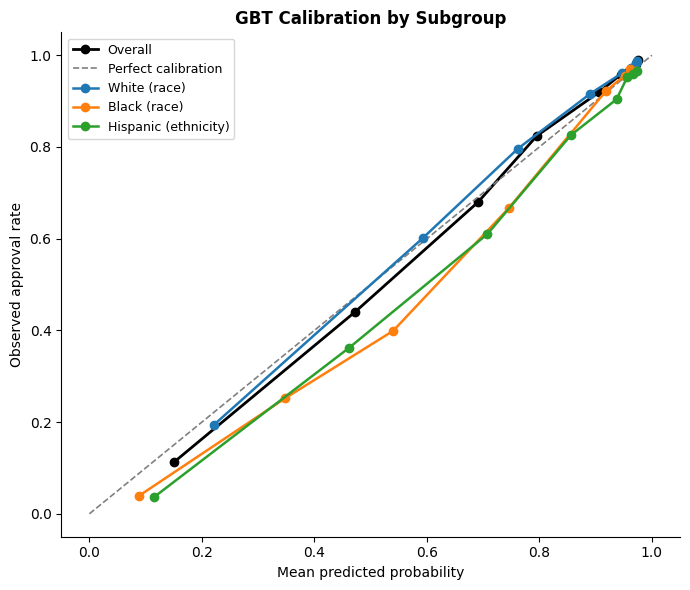

               group     n  approval_rate  mean_pred_prob  brier_score
        White (race) 20769         0.8015          0.7902       0.0871
        Black (race)  3074         0.6451          0.6895       0.1123
Hispanic (ethnicity)  3489         0.7016          0.7466       0.1091
Figure saved: gbt_subgroup_calibration.png


In [41]:
# 17.7) SUBGROUP CALIBRATION — GBT MODEL
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

print("=== Failure Mode #6: Subgroup Calibration Drift ===")

gbt_prob_test = gbt_pipeline.predict_proba(X_test)[:, 1]

subgroups = {
    "White (race)": audit_test["derived_race"].astype(str).eq("White").values,
    "Black (race)": audit_test["derived_race"].astype(str).eq("Black or African American").values,
    "Hispanic (ethnicity)": audit_test["derived_ethnicity"].astype(str).eq("Hispanic or Latino").values,
}

fig, ax = plt.subplots(figsize=(7, 6))

# overall reference
frac_all, pred_all = calibration_curve(y_test, gbt_prob_test, n_bins=10, strategy="quantile")
ax.plot(pred_all, frac_all, marker="o", linewidth=2, label="Overall", color="black")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.2, label="Perfect calibration")

cal_rows = []
for name, mask in subgroups.items():
    y_g = y_test.reset_index(drop=True)[mask]
    p_g = gbt_prob_test[mask]

    if len(y_g) < 100 or y_g.nunique() < 2:
        continue

    frac_g, pred_g = calibration_curve(y_g, p_g, n_bins=8, strategy="quantile")
    ax.plot(pred_g, frac_g, marker="o", linewidth=1.8, label=name)

    cal_rows.append({
        "group": name,
        "n": int(len(y_g)),
        "approval_rate": round(float(np.mean(y_g)), 4),
        "mean_pred_prob": round(float(np.mean(p_g)), 4),
        "brier_score": round(float(brier_score_loss(y_g, p_g)), 4)
    })

ax.set_title("GBT Calibration by Subgroup", fontsize=12, fontweight="bold")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed approval rate")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("gbt_subgroup_calibration.png", dpi=150, bbox_inches="tight")
plt.show()

subgroup_calibration_df = pd.DataFrame(cal_rows)
print(subgroup_calibration_df.to_string(index=False))
print("Figure saved: gbt_subgroup_calibration.png")

### Counterfactual flip para denied decisions
combined_loan_to_value_ratio and income

In [42]:
# 17.8) COUNTERFACTUAL FLIP FOR DENIED DECISIONS (GBT, threshold = 0.50)
print("=== Failure Mode #7: Counterfactual Flip for Denied Decisions ===")

decision_threshold = 0.50
gbt_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
gbt_pred = (gbt_prob >= decision_threshold).astype(int)

# denied decisions from the model's point of view
denied_idx = np.where(gbt_pred == 0)[0]

# sample up to 10 denied applicants with usable numeric fields
candidate_idx = []
for i in denied_idx:
    row = X_test.iloc[i]
    if pd.notna(row["combined_loan_to_value_ratio"]) or pd.notna(row["income"]):
        candidate_idx.append(i)
    if len(candidate_idx) >= 10:
        break

def score_row(row_df):
    return float(gbt_pipeline.predict_proba(row_df)[:, 1][0])

def find_flip_for_row(row_df, threshold=0.50):
    base_prob = score_row(row_df)
    best = None

    # Option A: reduce CLTV
    if pd.notna(row_df["combined_loan_to_value_ratio"].iloc[0]):
        original = float(row_df["combined_loan_to_value_ratio"].iloc[0])
        lower_bound = max(1.0, original * 0.60)
        grid = np.linspace(original, lower_bound, 30)

        for new_val in grid:
            trial = row_df.copy()
            trial["combined_loan_to_value_ratio"] = float(new_val)
            new_prob = score_row(trial)
            if new_prob >= threshold:
                pct_change = abs(new_val - original) / max(abs(original), 1.0)
                best = {
                    "feature_changed": "combined_loan_to_value_ratio",
                    "original_value": round(original, 4),
                    "counterfactual_value": round(float(new_val), 4),
                    "pct_change": round(float(pct_change), 4),
                    "new_prob": round(float(new_prob), 4)
                }
                break

    # Option B: increase income
    if pd.notna(row_df["income"].iloc[0]):
        original = float(row_df["income"].iloc[0])
        if original <= 0:
            upper_bound = float(pd.to_numeric(X_test["income"], errors="coerce").quantile(0.90))
        else:
            upper_bound = original * 1.75

        grid = np.linspace(original, upper_bound, 30)

        for new_val in grid:
            trial = row_df.copy()
            trial["income"] = float(new_val)
            new_prob = score_row(trial)
            if new_prob >= threshold:
                pct_change = abs(new_val - original) / max(abs(original), 1.0)
                cand = {
                    "feature_changed": "income",
                    "original_value": round(original, 4),
                    "counterfactual_value": round(float(new_val), 4),
                    "pct_change": round(float(pct_change), 4),
                    "new_prob": round(float(new_prob), 4)
                }
                if best is None or cand["pct_change"] < best["pct_change"]:
                    best = cand
                break

    return base_prob, best

cf_rows = []
for idx in candidate_idx:
    row_df = X_test.iloc[[idx]].copy()
    base_prob, best = find_flip_for_row(row_df, threshold=decision_threshold)

    record = {
        "test_index": int(idx),
        "base_prob": round(float(base_prob), 4),
        "denied_at_threshold": decision_threshold
    }

    if best is None:
        record.update({
            "feature_changed": "No flip found in search grid",
            "original_value": np.nan,
            "counterfactual_value": np.nan,
            "pct_change": np.nan,
            "new_prob": np.nan
        })
    else:
        record.update(best)

    cf_rows.append(record)

counterfactual_flip_df = pd.DataFrame(cf_rows)
print(counterfactual_flip_df.to_string(index=False))

=== Failure Mode #7: Counterfactual Flip for Denied Decisions ===
 test_index  base_prob  denied_at_threshold              feature_changed  original_value  counterfactual_value  pct_change  new_prob
          6     0.0316                  0.5 No flip found in search grid             NaN                   NaN         NaN       NaN
          7     0.4236                  0.5 No flip found in search grid             NaN                   NaN         NaN       NaN
         13     0.4163                  0.5 No flip found in search grid             NaN                   NaN         NaN       NaN
         23     0.4564                  0.5 No flip found in search grid             NaN                   NaN         NaN       NaN
         26     0.0401                  0.5 No flip found in search grid             NaN                   NaN         NaN       NaN
         32     0.0281                  0.5 No flip found in search grid             NaN                   NaN         NaN       NaN
   